In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.5
numpy: 2.5.2


In [2]:
df_casas=pd.read_csv('./data/house-prices-tp.csv')

In [3]:
df_casas

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0715,0.0000,4.4900,0.0000,0.4490,6.1210,56.8000,3.7476,3.0000,247.0000,18.5000,395.1500,8.4400,22.2000
1,0.0827,0.0000,13.9200,0.0000,0.4370,6.1270,18.4000,5.5027,4.0000,289.0000,16.0000,396.9000,8.5800,23.9000
2,0.1282,12.5000,6.0700,0.0000,0.4090,5.8850,33.0000,6.4980,4.0000,345.0000,18.9000,396.9000,8.7900,20.9000
3,0.0887,21.0000,5.6400,0.0000,0.4390,5.9630,45.7000,6.8147,4.0000,243.0000,16.8000,395.5600,13.4500,19.7000
4,0.1143,0.0000,8.5600,0.0000,0.5200,6.7810,71.3000,2.8561,5.0000,384.0000,20.9000,395.5800,7.6700,26.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
551,0.0824,30.0000,4.9300,0.0000,0.4280,6.4810,18.5000,6.1899,6.0000,300.0000,16.6000,379.4100,6.3600,23.7000
552,0.4755,0.0000,9.9000,0.0000,0.5440,6.1130,58.8000,4.0019,4.0000,304.0000,18.4000,396.2300,12.7300,21.0000
553,0.2498,0.0000,21.8900,0.0000,0.6240,5.8570,98.2000,1.6686,4.0000,437.0000,21.2000,392.0400,21.3200,13.3000
554,32.5040,6.5286,8.9373,1.0000,NaN,4.0166,NaN,5.2438,20.4169,197.2366,19.6391,6.2671,7.0340,23.0288


In [4]:
df_casas.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [5]:
df_casas.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,533.0000,534.0000,541.0000,533.0000,532.0000,535.0000,532.0000,541.0000,528.0000,538.0000,528.0000,534.0000,534.0000,535.0000
mean,5.8455,13.1972,11.2187,0.0901,0.5600,6.2918,67.6323,3.9441,9.6994,409.5751,18.4299,347.8060,13.0281,22.7468
std,13.8286,24.9030,6.9420,0.2865,0.1195,0.7824,28.4619,2.2557,8.6845,167.6894,2.1948,99.6362,7.5800,9.4915
min,0.0063,0.0000,0.4600,0.0000,0.3850,3.5610,2.9000,1.1296,1.0000,187.0000,12.6000,0.3200,1.7300,5.0000
25%,0.0845,0.0000,5.1300,0.0000,0.4530,5.8755,42.2750,2.1121,4.0000,279.0000,17.0000,369.5300,7.1500,16.7500
50%,0.3153,0.0000,9.6900,0.0000,0.5380,6.2080,76.5000,3.3401,5.0000,335.0000,19.0000,390.8150,11.4650,21.2000
75%,4.8714,20.0000,18.1000,0.0000,0.6440,6.6385,93.8250,5.4007,23.6327,666.0000,20.2000,395.8900,17.2050,26.3000
max,88.9762,100.0000,27.7400,1.0000,0.8710,8.7800,100.0000,12.1265,24.0000,711.0000,22.0000,396.9000,37.9700,50.0000


### ¿Qué observamos a priori?

Casi todas las variables son **asimétricas** (la media se aleja de la mediana), por eso más adelante usamos herramientas robustas a los extremos: IQR, Spearman y `RobustScaler`.

- `CRIM`: media 4.99 contra mediana 0.29; unos pocos barrios muy peligrosos arrastran el promedio.
- `ZN`: mediana 0; 7 de cada 10 barrios valen cero (*zero-inflated*).
- `INDUS` y `RM`: casi simétricas (skew 0.30 y 0.27).
- `NOX`: vive entre 0 y 1, una escala muy distinta al resto; sin escalar pesaría poco en las distancias de KNN.
- `AGE` y `PTRATIO`: cola hacia valores bajos (skew -0.55 y -0.78).
- `DIS`, `LSTAT` y `MEDV`: cola hacia valores altos (skew 1.06, 0.96 y 1.06). En `MEDV`, el target, la estiran barrios cercanos al techo de 50.
- `TAX`: correlaciona ~0.89 con `RAD`, señal de multicolinealidad.
- `B`: cola fuerte hacia valores bajos (skew -2.56); esa minoría es la parte más informativa de la variable.
- `CHAS`: binaria y desbalanceada (91% de ceros). Promediarla con KNN daría valores inválidos como 0.3, así que la imputamos con `CatBoostClassifier`.
- `RAD`: discreta, con dominio {1, ..., 8, 24}, bimodal y con valores inválidos (por ejemplo 3.7). Tampoco se promedia con KNN.


## Carga e inspección del dataset

556 registros y 14 variables. Es un problema de **regresión**: predecir `MEDV` (continua) a partir de las otras 13.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `CRIM` | Continua | Tasa de criminalidad per cápita por municipio |
| `ZN` | Continua | Proporción de suelo residencial zonificado para lotes de más de 25.000 pies cuadrados |
| `INDUS` | Continua | Proporción de acres comerciales no minoristas por municipio |
| `CHAS` | Categórica | Variable ficticia del río Charles (1 si limita con el río; 0 en caso contrario) |
| `NOX` | Continua | Concentración de óxidos nítricos (indicador de contaminación del aire) |
| `RM` | Continua | Cantidad promedio de habitaciones por vivienda |
| `AGE` | Continua | Proporción de viviendas antiguas (construidas antes de 1940) ocupadas por sus dueños |
| `DIS` | Continua | Distancias ponderadas a cinco grandes centros de empleo |
| `RAD` | Discreta | Índice de accesibilidad a las autopistas radiales |
| `TAX` | Continua | Tasa de impuesto a la propiedad por cada $10.000 |
| `PTRATIO` | Continua | Proporción de alumnos por maestro en la zona |
| `B` | Continua | Índice matemático relacionado a la proporción de población afroamericana |
| `LSTAT` | Continua | Porcentaje de la población considerada de bajo estatus socioeconómico |
| `MEDV` | Continua | **Variable objetivo:** Valor mediano de las viviendas en miles de dólares ($1000s) |

### Nulos por columna

In [6]:
nulos = df_casas.isnull().sum()
pct_nulos = (nulos / len(df_casas)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        23          4.1367  float64
ZN          22          3.9568  float64
INDUS       15          2.6978  float64
CHAS        23          4.1367  float64
NOX         24          4.3165  float64
RM          21          3.7770  float64
AGE         24          4.3165  float64
DIS         15          2.6978  float64
RAD         28          5.0360  float64
TAX         18          3.2374  float64
PTRATIO     28          5.0360  float64
B           22          3.9568  float64
LSTAT       22          3.9568  float64
MEDV        21          3.7770  float64

Total de celdas con nulos: 306 (3.9311% del dataset)


`MEDV`, el target, tiene 21 nulos. Eliminamos esas filas: imputar el target sería inventar las respuestas que el modelo tiene que aprender.

In [7]:
df_casas['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 , 19.26689099,  3.05654826, 23.51021334, 17.11018134,
       18.17750289,  2.40242419,  4.52856858,  2.57361455, 22.32831295,
       14.19552773, 20.41690761])

In [8]:
df_casas_limpio = df_casas.dropna(subset=['MEDV'])

In [9]:
df_casas_limpio['RAD'].unique()

array([ 3.        ,  4.        ,  5.        ,  1.        ,  8.        ,
       24.        , 10.5548915 ,  7.        ,  2.        ,         nan,
        6.        , 14.63832996, 17.0001503 ,  6.85012281, 22.06951085,
        1.30712763, 17.16456963, 10.16870119, 21.90077626, 15.23957943,
        4.8117484 ,  3.05654826, 17.11018134,  2.40242419,  2.57361455,
       14.19552773, 20.41690761])

In [10]:
df_casas_limpio['RAD'] = df_casas_limpio['RAD'].round()
valores_validos_rad = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 24.0]

# Los valores fuera de las categorías válidas de RAD (incluidos los que ya eran nulos)
# se marcan como NaN, para imputarlos mas adelante con CatBoostClassifier junto con CHAS
df_casas_limpio.loc[~df_casas_limpio['RAD'].isin(valores_validos_rad), 'RAD'] = np.nan

In [11]:
nulos = df_casas_limpio.isnull().sum()
pct_nulos = (nulos / len(df_casas_limpio)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df_casas_limpio.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df_casas_limpio.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)     Tipo
CRIM        11          2.0561  float64
ZN          11          2.0561  float64
INDUS        4          0.7477  float64
CHAS         9          1.6822  float64
NOX          9          1.6822  float64
RM           7          1.3084  float64
AGE         11          2.0561  float64
DIS          5          0.9346  float64
RAD         23          4.2991  float64
TAX          9          1.6822  float64
PTRATIO      9          1.6822  float64
B            9          1.6822  float64
LSTAT        9          1.6822  float64
MEDV         0          0.0000  float64

Total de celdas con nulos: 126 (1.6822% del dataset)


Con eso, el porcentaje de nulos del resto de las columnas baja a menos de la mitad.

### Filas con algún nulo

In [12]:
df_nulos = df_casas_limpio[df_casas_limpio.isnull().any(axis=1)]
df_nulos

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
14,30.9865,60.7115,8.8272,0.0000,0.7476,NaN,23.5934,5.0625,NaN,621.3307,16.6349,60.1620,30.4948,23.6754
23,73.6057,90.4347,12.7403,0.0000,NaN,8.0501,22.5424,5.7312,NaN,NaN,21.2916,NaN,NaN,28.1301
66,NaN,57.3495,3.0478,1.0000,0.8139,4.3715,42.0051,NaN,NaN,260.0063,16.8671,95.2918,NaN,30.0891
88,NaN,51.4067,NaN,NaN,NaN,NaN,8.0227,NaN,NaN,NaN,18.3460,NaN,NaN,35.8650
128,NaN,NaN,13.6140,1.0000,0.6554,6.9344,26.1907,10.5900,7.0000,433.5793,12.7216,81.8895,NaN,12.9376
158,NaN,16.0260,NaN,0.0000,0.8158,7.6807,16.3767,10.7724,NaN,NaN,NaN,99.9282,NaN,49.0005
172,48.3319,12.3063,25.4002,1.0000,0.7618,NaN,77.5480,10.3482,NaN,NaN,15.5791,219.0445,29.7366,14.4423
203,2.0876,NaN,3.7731,NaN,NaN,NaN,72.4877,1.8957,NaN,592.6382,15.3468,NaN,36.2203,45.2828
223,NaN,NaN,15.5236,NaN,NaN,NaN,35.5404,1.9678,1.0000,NaN,13.3648,200.6252,NaN,40.6947
230,23.7853,67.3783,21.0065,0.0000,0.8591,8.4211,70.7801,5.8163,NaN,NaN,20.1837,370.9914,9.3324,24.2417


Máximo de nulos por fila, para fijar un umbral de descarte.

### Descartamos las filas con 50% o más de faltantes

In [13]:
df_casas_limpio = df_casas_limpio.dropna(thresh=len(df_casas_limpio.columns)*0.5)
df_casas_limpio.info()

<class 'pandas.DataFrame'>
Index: 531 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     524 non-null    float64
 1   ZN       521 non-null    float64
 2   INDUS    530 non-null    float64
 3   CHAS     525 non-null    float64
 4   NOX      525 non-null    float64
 5   RM       526 non-null    float64
 6   AGE      523 non-null    float64
 7   DIS      529 non-null    float64
 8   RAD      512 non-null    float64
 9   TAX      523 non-null    float64
 10  PTRATIO  524 non-null    float64
 11  B        525 non-null    float64
 12  LSTAT    525 non-null    float64
 13  MEDV     531 non-null    float64
dtypes: float64(14)
memory usage: 62.2 KB


Se eliminan 4 filas (quedan 531).

### Columnas numéricas

Excluimos `CHAS` y `RAD`, que son categóricas, del análisis de distribuciones y outliers.

In [14]:
columnas_numericas = [col for col in df_casas_limpio.columns if col != 'CHAS' and col != 'RAD']


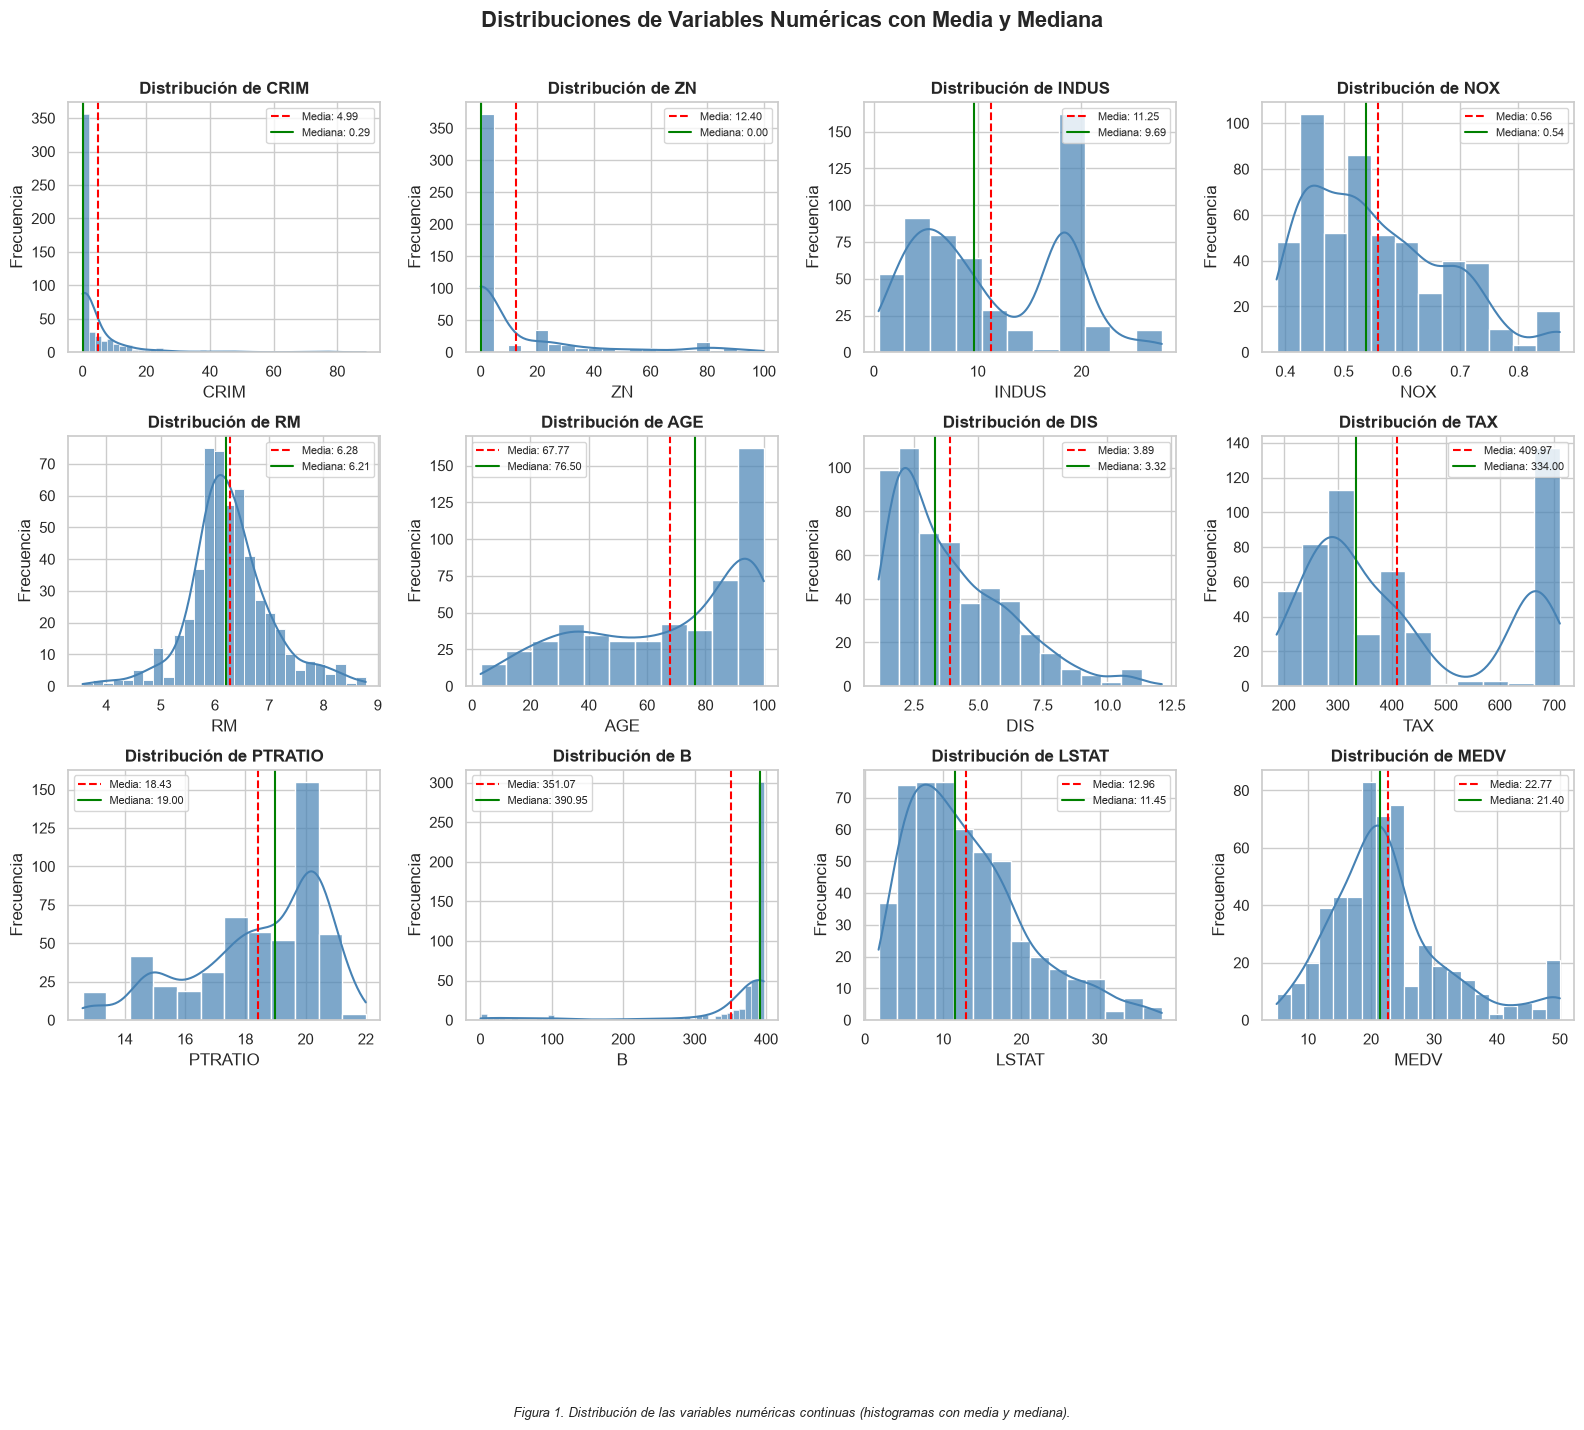

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    sns.histplot(df_casas_limpio[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Líneas de referencia: media y mediana
    media = df_casas_limpio[col].mean()
    mediana = df_casas_limpio[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivamos los ejes basándonos en la nueva cantidad de columnas
for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numéricas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.05)
plt.figtext(0.5, 0.005, 'Figura 1. Distribución de las variables numéricas continuas (histogramas con media y mediana).',
            ha='center', fontsize=9, style='italic')
plt.show()

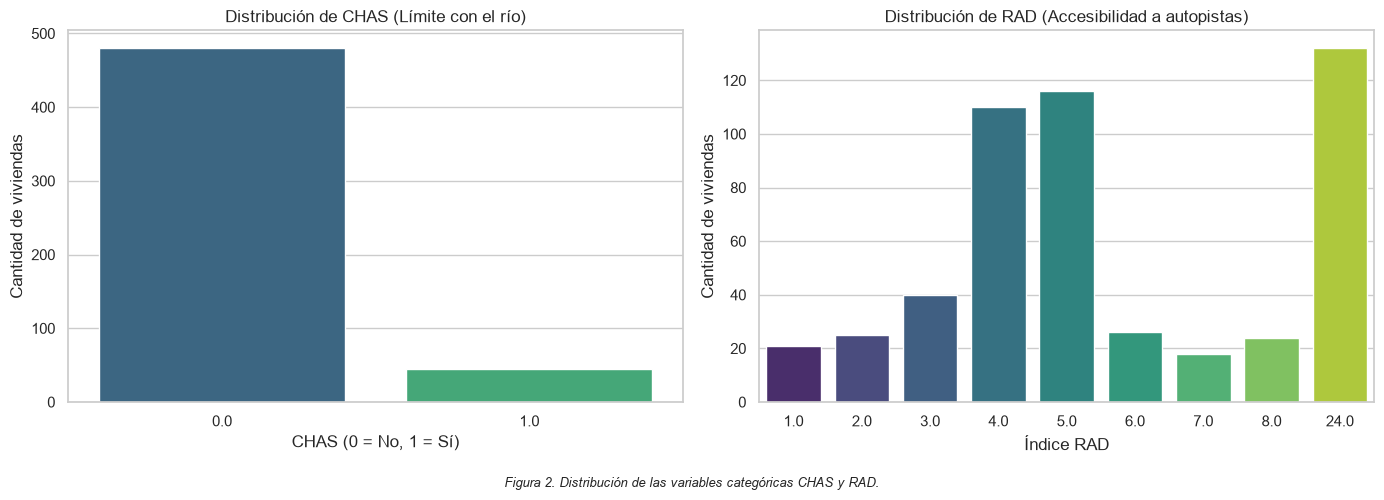

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_casas_limpio, x='CHAS', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de CHAS (Límite con el río)')
axes[0].set_xlabel('CHAS (0 = No, 1 = Sí)')
axes[0].set_ylabel('Cantidad de viviendas')

sns.countplot(data=df_casas_limpio, x='RAD', ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de RAD (Accesibilidad a autopistas)')
axes[1].set_xlabel('Índice RAD')
axes[1].set_ylabel('Cantidad de viviendas')

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.01, 'Figura 2. Distribución de las variables categóricas CHAS y RAD.',
            ha='center', fontsize=9, style='italic')
plt.show()

### Lectura de los gráficos

Balance de `CHAS` y distribución de `RAD`, que después usamos para decidir cómo escalarlas e imputarlas.

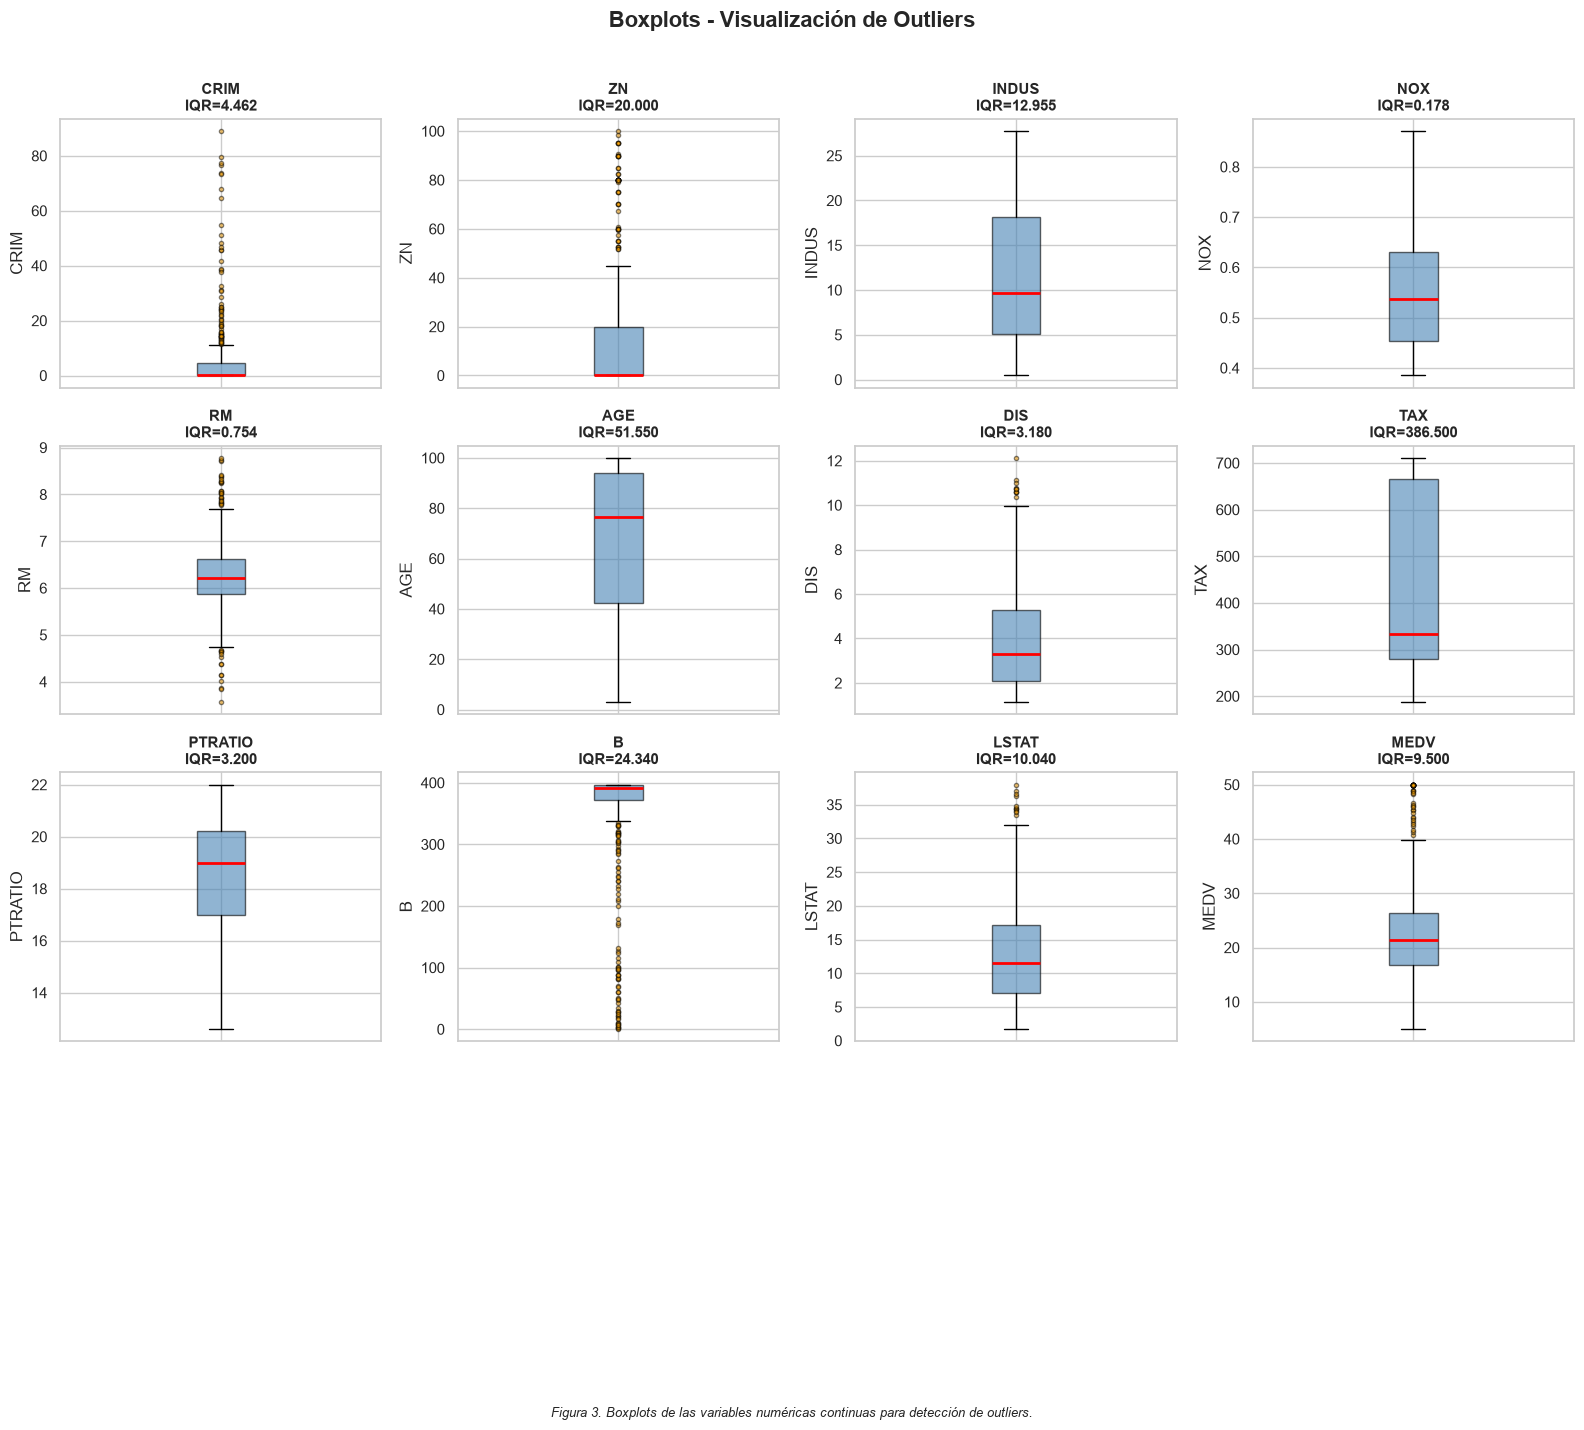

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    ax = axes[i]
    datos = df_casas_limpio[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(columnas_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualización de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.subplots_adjust(bottom=0.04)
plt.figtext(0.5, 0.005, 'Figura 3. Boxplots de las variables numéricas continuas para detección de outliers.',
            ha='center', fontsize=9, style='italic')
plt.show()

In [18]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,CRIM,0.4593,0.0000,474.8110,0.0000,No
1,ZN,0.5797,0.0000,212.0894,0.0000,No
2,INDUS,0.9066,0.0000,358.1683,0.0000,No
3,NOX,0.9363,0.0000,37.7920,0.0000,No
4,RM,0.9649,0.0000,26.3030,0.0000,No
5,AGE,0.8942,0.0000,154.8825,0.0000,No
6,DIS,0.9001,0.0000,78.4015,0.0000,No
7,TAX,0.8243,0.0000,307.0383,0.0000,No
8,PTRATIO,0.9067,0.0000,46.7652,0.0000,No
9,B,0.5156,0.0000,280.3340,0.0000,No


Los tests de Shapiro-Wilk y D'Agostino-Pearson rechazan la normalidad, así que en lugar del z-score usamos el método IQR, basado en cuartiles.

In [19]:
IQR_FACTOR = 1.5

reporte_outliers = []

for col in columnas_numericas:
    datos = df_casas_limpio[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)']]

Reporte de Outliers: Metodo IQR


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%)
0,CRIM,524,4.4619,-6.6092,11.2382,64,12.2137
1,ZN,521,20.0000,-30.0000,50.0000,54,10.3647
2,INDUS,530,12.9550,-14.2875,37.5325,0,0.0000
3,NOX,525,0.1780,0.1860,0.8980,0,0.0000
4,RM,526,0.7545,4.7445,7.7625,41,7.7947
5,AGE,523,51.5500,-34.9750,171.2250,0,0.0000
6,DIS,529,3.1804,-2.6637,10.0579,10,1.8904
7,TAX,523,386.5000,-300.2500,1245.7500,0,0.0000
8,PTRATIO,524,3.2000,12.2000,25.0000,0,0.0000
9,B,525,24.3400,335.2100,432.5700,86,16.3810


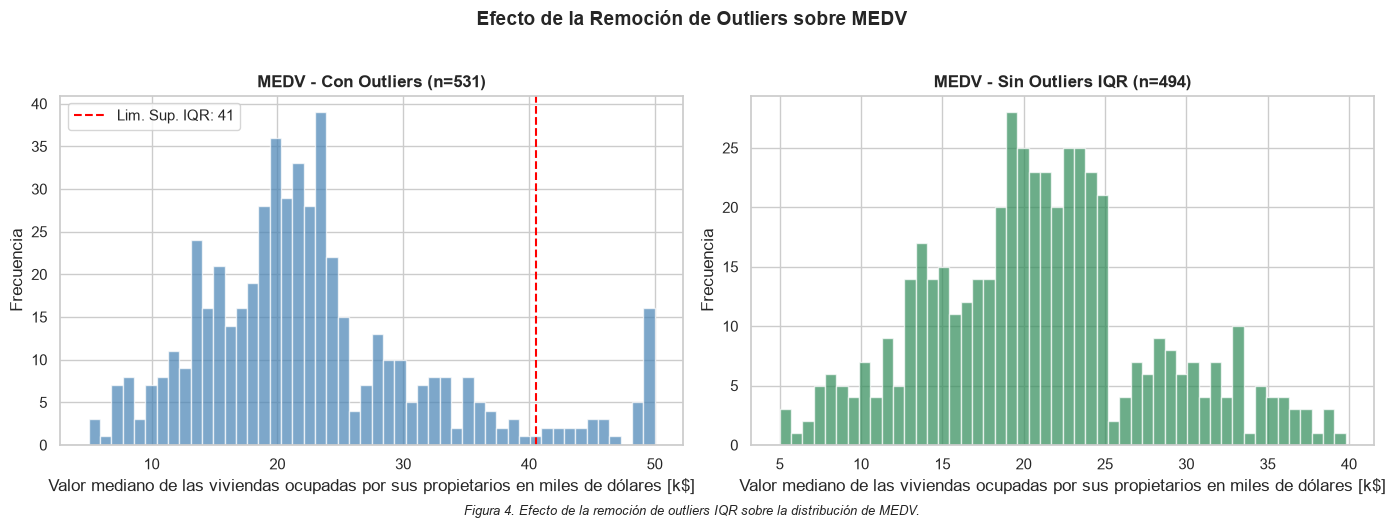

Registros eliminados: 37 (6.97%)


In [20]:
col_ejemplo = 'MEDV'
datos = df_casas_limpio[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Valor mediano de las viviendas ocupadas por sus propietarios en miles de dólares [k$]')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remoción de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 4. Efecto de la remoción de outliers IQR sobre la distribución de MEDV.',
            ha='center', fontsize=9, style='italic')
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

In [21]:
matriz_pearson = df_casas_limpio.corr(method='pearson')
matriz_spearman = df_casas_limpio.corr(method='spearman')


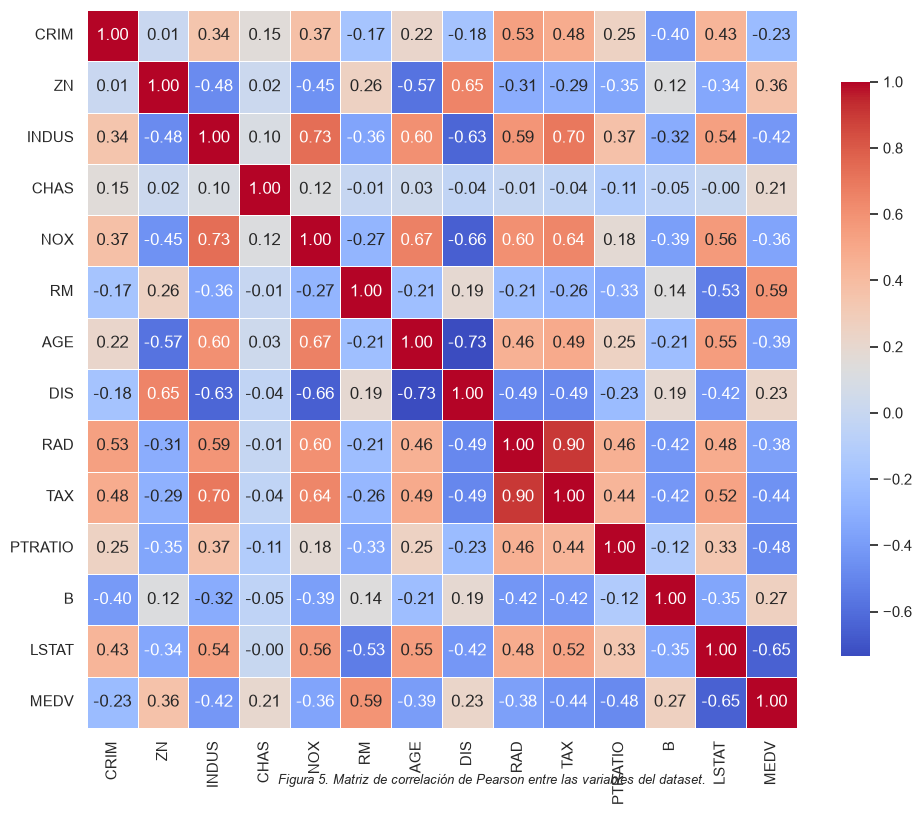

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=matriz_pearson, 
    annot=True,            # Muestra el valor numérico dentro de cada celda
    fmt=".2f",             # Formato del número (ej. ".2f" para 2 decimales, "d" para enteros)
    cmap="coolwarm",       # Paleta de colores atractiva
    linewidths=0.5,        # Agrega líneas de separación entre las celdas
    linecolor='white',     # Color de las líneas de separación
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra de colores lateral
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.figtext(0.5, 0.01, 'Figura 5. Matriz de correlación de Pearson entre las variables del dataset.',
            ha='center', fontsize=9, style='italic')
plt.show()

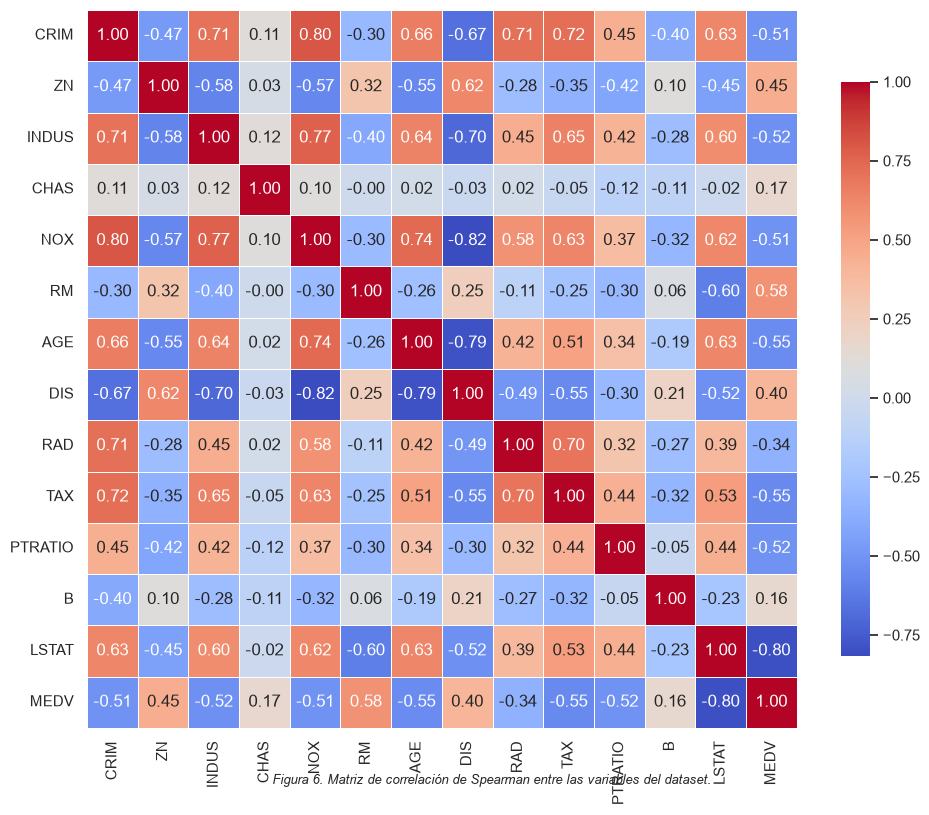

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    data=matriz_spearman, 
    annot=True,            # Muestra el valor numérico dentro de cada celda
    fmt=".2f",             # Formato del número (ej. ".2f" para 2 decimales, "d" para enteros)
    cmap="coolwarm",       # Paleta de colores atractiva
    linewidths=0.5,        # Agrega líneas de separación entre las celdas
    linecolor='white',     # Color de las líneas de separación
    cbar_kws={"shrink": .8} # Ajusta el tamaño de la barra de colores lateral
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.figtext(0.5, 0.01, 'Figura 6. Matriz de correlación de Spearman entre las variables del dataset.',
            ha='center', fontsize=9, style='italic')
plt.show()

## Conclusiones de la matriz de correlación

Tomamos Spearman (Figura 6) como referencia: trabaja con rangos, así que no lo distorsionan los outliers ni las asimetrías que rompen los supuestos de Pearson (Figura 5).

1. `RAD`-`TAX`: 0.89 con Pearson y 0.69 con Spearman, **multicolinealidad** real. Las zonas más urbanizadas tienen impuestos más altos y mejor acceso a autopistas.
2. `CRIM`: con Pearson parece aislada (`CRIM`-`ZN` = 0.01), pero con Spearman aparece conectada (`CRIM`-`NOX` = 0.80, `CRIM`-`TAX` = 0.72). Unos pocos barrios extremos distorsionan el coeficiente lineal.


## Coherencia de los outliers (CRIM, ZN y B)

IQR marca muchos outliers en estas variables, pero casi todos son la cola de distribuciones asimétricas y no errores de carga. Contrastamos cada uno con las relaciones que predice la matriz de correlación: si rompe la mayoría, lo marcamos como incoherente.

In [24]:
def detectar_outliers_iqr(df, columna):
    serie = df[columna].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    df_outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)].copy()
    df_outliers['lado'] = np.where(df_outliers[columna] > lim_sup, 'alto', 'bajo')
    return df_outliers, lim_inf, lim_sup

### Función: chequear coherencia

Compara cada outlier contra la mediana de las variables relacionadas y cuenta cuántas relaciones esperadas rompe.

- `direccion`: signo de la correlación con el target (+1 o -1).
- `relaciones`: `{variable: signo_esperado}` para otras variables del dominio.
- `umbral_fraccion`: fracción de relaciones rotas a partir de la cual la fila es incoherente.

Los NaN no se evalúan: solo achican el denominador.

In [25]:
def chequear_coherencia(df, columna, direccion, relaciones=None, target='MEDV',
                         umbral_fraccion=0.5):
    df_outliers, lim_inf, lim_sup = detectar_outliers_iqr(df, columna)
    signo_lado = np.where(df_outliers['lado'] == 'alto', 1, -1)

    def marca_rompe(var, signo_esperado):
        mediana_var = df[var].median(skipna=True)
        diff = df_outliers[var] - mediana_var
        signo_fila = np.sign(diff)
        signo_esperado_fila = signo_lado * signo_esperado
        evaluable = diff.notna() & (signo_fila != 0)
        rompe = evaluable & (np.sign(signo_esperado_fila) != signo_fila)
        return evaluable, rompe

    todas_las_relaciones = [(target, direccion)] + list((relaciones or {}).items())
    n_evaluables = pd.Series(0, index=df_outliers.index)
    n_rotas = pd.Series(0, index=df_outliers.index)
    for var, signo_var in todas_las_relaciones:
        evaluable, rompe = marca_rompe(var, signo_var)
        df_outliers[f'rompe_{var}'] = rompe
        n_evaluables += evaluable.astype(int)
        n_rotas += rompe.astype(int)

    df_outliers['n_evaluables'] = n_evaluables
    df_outliers['n_rotas'] = n_rotas
    df_outliers['fraccion_rota'] = np.where(n_evaluables > 0, n_rotas / n_evaluables, 0.0)

    df_incoherentes = (
        df_outliers[(df_outliers['n_evaluables'] > 0) &
                    (df_outliers['fraccion_rota'] >= umbral_fraccion)]
        .sort_values(['fraccion_rota', 'n_evaluables'], ascending=False)
    )

    print(f"--- {columna} ---")
    print(f"  límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}]  -> {len(df_outliers)} outliers totales")
    print(f"  incoherentes (rompen >={umbral_fraccion*100:.0f}% de lo evaluable): {len(df_incoherentes)}")

    return df_outliers, df_incoherentes

### Función: graficar coherencia

Outliers contra `MEDV`, separados en coherentes (se conservan) e incoherentes (a revisar).

In [26]:
def graficar_coherencia(df, columna, df_outliers, df_incoherentes, target='MEDV', fig_num=None):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=columna, y=target, color='lightgrey', alpha=0.6,
                     label='Datos normales')

    coherentes = df_outliers.drop(df_incoherentes.index)
    sns.scatterplot(data=coherentes, x=columna, y=target, color='orange', edgecolor='black',
                     label='Outlier coherente (conservar)')

    sns.scatterplot(data=df_incoherentes, x=columna, y=target, color='red', edgecolor='black',
                     s=90, label='Outlier incoherente (revisar)')

    plt.title(f'Coherencia de outliers de {columna} respecto a {target}')
    plt.xlabel(columna)
    plt.ylabel(target)
    plt.legend()
    if fig_num is not None:
        plt.subplots_adjust(bottom=0.14)
        plt.figtext(0.5, 0.01, f'Figura {fig_num}. Coherencia de outliers de {columna} respecto a {target}.',
                    ha='center', fontsize=9, style='italic')
    plt.show()

### Signos esperados por variable

Salen de la matriz de correlación:

- `CRIM`: negativo con `MEDV`, negativo con `RM`, positivo con `LSTAT`.
- `ZN`: positivo con `MEDV`, negativo con `INDUS`, negativo con `LSTAT`.
- `B`: positivo con `MEDV`, negativo con `LSTAT`.

In [27]:
config = {
    'CRIM': dict(direccion=-1, relaciones={'RM': -1, 'LSTAT': 1}),
    'ZN':   dict(direccion=+1, relaciones={'INDUS': -1, 'LSTAT': -1}),
    'B':    dict(direccion=+1, relaciones={'LSTAT': -1}),
}

### Análisis de CRIM, ZN y B

Con `umbral_fraccion=0.5`, una fila es incoherente si rompe la mayoría de sus relaciones evaluables.

--- CRIM ---
  límites IQR: [-6.61, 11.24]  -> 64 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 10


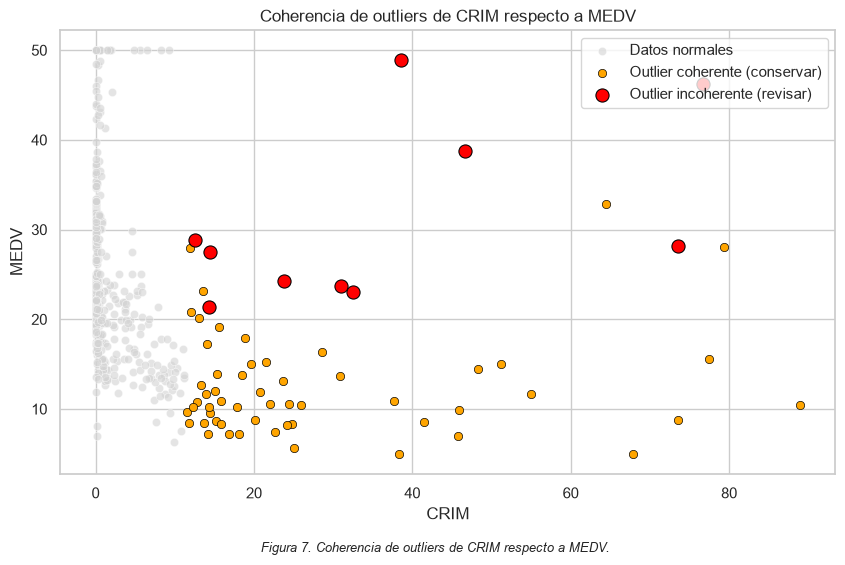

--- ZN ---
  límites IQR: [-30.00, 50.00]  -> 54 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 6


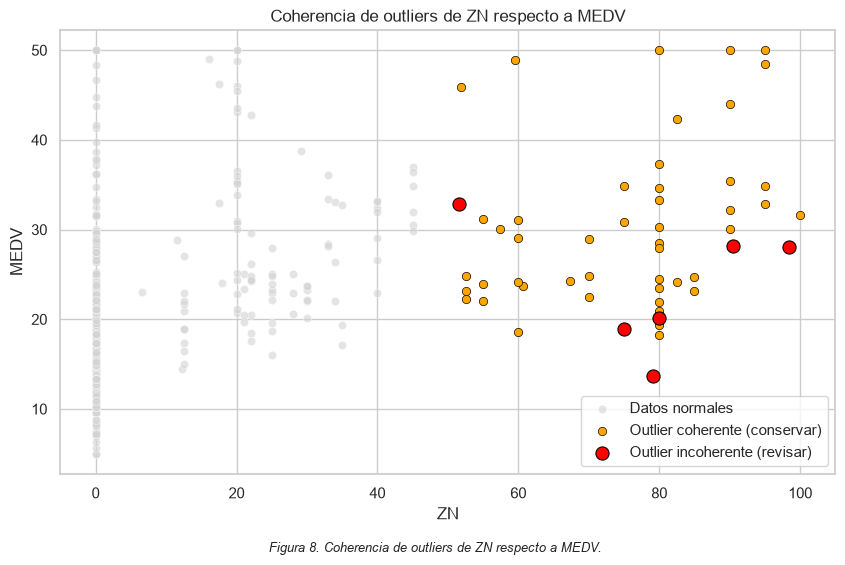

--- B ---
  límites IQR: [335.21, 432.57]  -> 86 outliers totales
  incoherentes (rompen >=50% de lo evaluable): 21


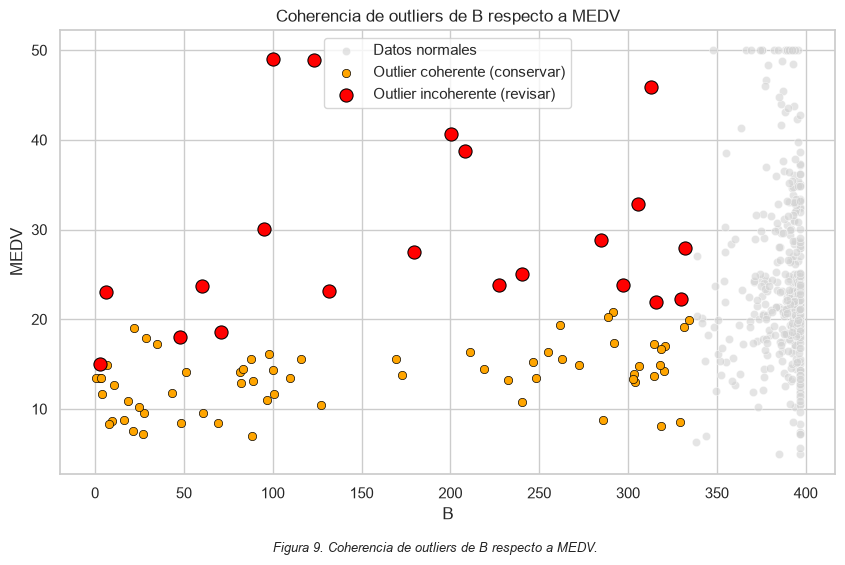

In [28]:
resultados = {}
for i, (col, cfg) in enumerate(config.items()):
    outliers, incoherentes = chequear_coherencia(df_casas_limpio, col, **cfg, umbral_fraccion=0.5)
    resultados[col] = (outliers, incoherentes)
    graficar_coherencia(df_casas_limpio, col, outliers, incoherentes, fig_num=7 + i)

### Triangulación entre variables

Una fila incoherente en más de una variable es un candidato más fuerte a revisión que una incoherente en una sola.

In [29]:
indices = [set(incoh.index) for _, incoh in resultados.values()]
interseccion = set.union(*[
    indices[i] & indices[j]
    for i in range(len(indices)) for j in range(i + 1, len(indices))
])

print('Filas incoherentes en más de una variable:', sorted(interseccion))

cols_mostrar = ['CRIM', 'ZN', 'B', 'RM', 'LSTAT', 'INDUS', 'MEDV']
df_casas_limpio.loc[sorted(interseccion), cols_mostrar]

Filas incoherentes en más de una variable: [14, 23, 264, 298, 316, 458, 520, 554]


,CRIM,ZN,B,RM,LSTAT,INDUS,MEDV
14,30.9865,60.7115,60.1620,NaN,30.4948,8.8272,23.6754
23,73.6057,90.4347,NaN,8.0501,NaN,12.7403,28.1301
264,38.6081,59.5613,123.4545,3.8395,3.3899,15.5515,48.8545
298,14.4383,0.0000,179.3600,6.8520,19.7800,18.1000,27.5000
316,46.6368,29.0858,208.3193,4.5902,9.7974,23.6764,38.7155
458,12.5105,11.6104,284.7875,7.9491,27.7894,14.4042,28.8124
520,64.4546,51.5727,305.3963,5.6565,33.9643,12.8320,32.8579
554,32.5040,6.5286,6.2671,4.0166,7.0340,8.9373,23.0288


## Separación en train y test, e imputación con KNNImputer

Hacemos el split antes de cualquier transformación para evitar **fuga de datos**: nada del preprocesamiento puede usar información de test. Las filas trianguladas se eliminan solo si cayeron en train; test queda intacto, como los datos reales.

In [30]:
from sklearn.model_selection import train_test_split

X = df_casas_limpio.drop(columns='MEDV')
y = df_casas_limpio['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

filas_a_eliminar = sorted(interseccion)
filas_en_train = [i for i in filas_a_eliminar if i in X_train.index]
filas_en_test = [i for i in filas_a_eliminar if i in X_test.index]

print(f'Se eliminan de train: {filas_en_train}')
print(f'Se conservan en test (aunque estén en la lista): {filas_en_test}')

X_train = X_train.drop(index=filas_en_train)
y_train = y_train.drop(index=filas_en_train)

Se eliminan de train: [14, 23, 264, 298, 316, 458, 554]
Se conservan en test (aunque estén en la lista): [520]


### Escalado con RobustScaler

Usa mediana e IQR, así que no lo arrastran los outliers legítimos que conservamos en `CRIM`, `ZN` y `B`, como pasaría con `StandardScaler`. Se ajusta con train y se aplica a test.

In [31]:
from sklearn.preprocessing import RobustScaler

columnas_continuas = [c for c in X_train.columns if c not in ['CHAS', 'RAD']]

scaler = RobustScaler()
X_train_esc = X_train.copy()
X_train_esc[columnas_continuas] = scaler.fit_transform(X_train[columnas_continuas])

X_test_esc = X_test.copy()
X_test_esc[columnas_continuas] = scaler.transform(X_test[columnas_continuas])

### Efecto del escalado

Antes y después de `RobustScaler`: medianas centradas y escalas comparables entre variables.

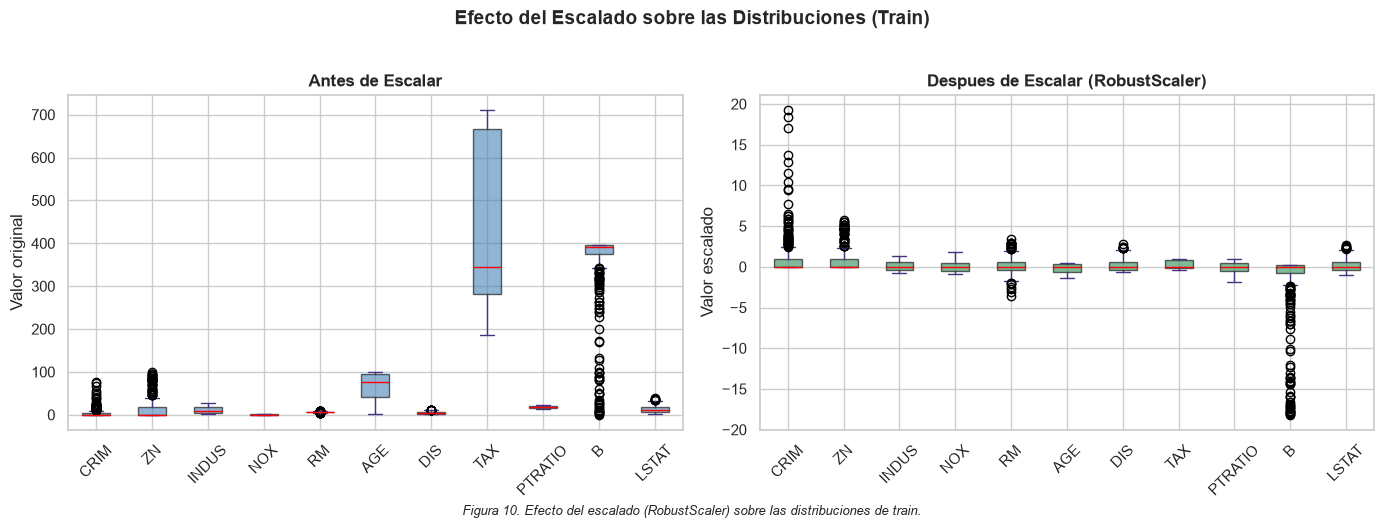

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
X_train[columnas_continuas].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Escalar', fontweight='bold')
axes[0].set_ylabel('Valor original')
axes[0].tick_params(axis='x', rotation=45)

# Despues
X_train_esc[columnas_continuas].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Escalar (RobustScaler)', fontweight='bold')
axes[1].set_ylabel('Valor escalado')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto del Escalado sobre las Distribuciones (Train)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.figtext(0.5, 0.01, 'Figura 10. Efecto del escalado (RobustScaler) sobre las distribuciones de train.',
            ha='center', fontsize=9, style='italic')
plt.show()

## Método del codo para elegir `n_neighbors` (KNNImputer)

La cantidad de vecinos `k` es un **hiperparámetro**. Para elegirlo borramos a propósito valores conocidos de las filas completas de train, los imputamos con distintos `k` y medimos el error de reconstrucción (NRMSE). Todo con train, para no filtrar información de test.

In [33]:
from sklearn.impute import KNNImputer

### Función: enmascarar y medir

Oculta al azar una fracción de celdas, las imputa con `k` vecinos y devuelve el NRMSE sobre esas celdas, normalizado por el desvío de cada columna.

In [34]:
def enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng):
    mascara = rng.random(datos_verdad.shape) < fraccion_mascara
    datos_enmascarados = datos_verdad.copy()
    datos_enmascarados[mascara] = np.nan

    imputer = KNNImputer(n_neighbors=k)
    reconstruido = imputer.fit_transform(datos_enmascarados)

    std_cols = datos_verdad.std(axis=0)
    error = (reconstruido[mascara] - datos_verdad[mascara]) ** 2
    std_expandido = np.tile(std_cols, (datos_verdad.shape[0], 1))[mascara]
    return np.sqrt(np.mean(error / (std_expandido ** 2 + 1e-12)))

### Función: curva del codo

Repite el experimento `n_repeticiones` veces por cada `k` y devuelve la media y el desvío del NRMSE.

In [35]:
def curva_del_codo(datos_verdad, ks, n_repeticiones=15, fraccion_mascara=0.05):
    filas = []
    for k in ks:
        errores = []
        for rep in range(n_repeticiones):
            rng = np.random.default_rng(rep)
            errores.append(enmascarar_y_medir(datos_verdad, fraccion_mascara, k, rng))
        filas.append({
            'k': k,
            'nrmse_medio': np.mean(errores),
            'nrmse_std': np.std(errores),
        })
    return pd.DataFrame(filas)

### Función: graficar el codo

NRMSE promedio (± desvío) según `k`.

In [36]:
def graficar_codo(tabla_resultados):
    plt.figure(figsize=(9, 5))
    plt.plot(
        tabla_resultados['k'], tabla_resultados['nrmse_medio'],
        marker='o', linewidth=2
    )
    plt.title('Método del codo para elegir n_neighbors (KNNImputer)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('NRMSE promedio (experimento de enmascaramiento)')
    plt.grid(alpha=0.3)
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, 'Figura 11. Método del codo: NRMSE promedio vs. n_neighbors (k) para KNNImputer.',
                ha='center', fontsize=9, style='italic')
    plt.show()


### Función: elegir k por curvatura

Calcula el codo en vez de elegirlo a ojo: es el `k` con mayor derivada segunda del NRMSE en valor absoluto, donde la curva pasa más bruscamente de bajar a aplanarse. Cada derivada se divide por la distancia real entre los `k`, que no están espaciados de forma uniforme.

In [37]:
def calcular_derivadas_codo(tabla_resultados):
    tabla_ordenada = tabla_resultados.sort_values('k').reset_index(drop=True)
    k = tabla_ordenada['k'].to_numpy(dtype=float)
    y = tabla_ordenada['nrmse_medio'].to_numpy()

    # Derivada primera: pendiente del NRMSE entre cada par de k consecutivos
    derivada_1 = np.diff(y) / np.diff(k)
    k_medios = (k[1:] + k[:-1]) / 2

    # Derivada segunda: cuanto cambia la pendiente de un tramo al siguiente
    derivada_2 = np.diff(derivada_1) / np.diff(k_medios)
    k_curvatura = k[1:-1]

    return pd.DataFrame({'k': k_curvatura.astype(int), 'derivada_segunda': derivada_2})


def elegir_k_por_curvatura(tabla_resultados):
    derivadas = calcular_derivadas_codo(tabla_resultados)
    idx_codo = derivadas['derivada_segunda'].abs().idxmax()
    k_elegido = int(derivadas.loc[idx_codo, 'k'])
    return k_elegido, derivadas


### Función: graficar la curvatura del codo

Derivada segunda del NRMSE según `k`, con el codo marcado.

In [38]:
def graficar_curvatura_codo(derivadas, k_elegido):
    plt.figure(figsize=(9, 5))
    plt.plot(derivadas['k'], derivadas['derivada_segunda'], marker='o')
    plt.axvline(k_elegido, color='firebrick', linestyle='--', label=f'k elegido = {k_elegido}')
    plt.title('Curvatura de la curva del codo (derivada segunda del NRMSE)')
    plt.xlabel('n_neighbors (k)')
    plt.ylabel('Derivada segunda del NRMSE promedio')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.subplots_adjust(bottom=0.15)
    plt.figtext(0.5, 0.01, 'Figura 12. Derivada segunda del NRMSE vs. k: el maximo en valor absoluto marca el codo (mayor cambio de pendiente).',
                ha='center', fontsize=9, style='italic')
    plt.show()


### Ejecutamos el experimento

Solo con las filas completas de `X_train_esc`.

In [39]:
completas = X_train_esc[columnas_continuas].dropna().copy()
print(f'Filas completas en train usadas para el experimento: {completas.shape[0]}')

datos_verdad = completas.to_numpy()
ks_a_probar = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]

tabla = curva_del_codo(datos_verdad, ks_a_probar, n_repeticiones=15, fraccion_mascara=0.05)
tabla

Filas completas en train usadas para el experimento: 405


,k,nrmse_medio,nrmse_std
0,1,0.7390,0.0889
1,2,0.6477,0.0627
2,3,0.6314,0.0631
3,4,0.6248,0.0647
4,5,0.6227,0.0637
5,7,0.6312,0.0547
6,10,0.6374,0.0512
7,15,0.6524,0.0571
8,20,0.6636,0.0584
9,25,0.6727,0.0602


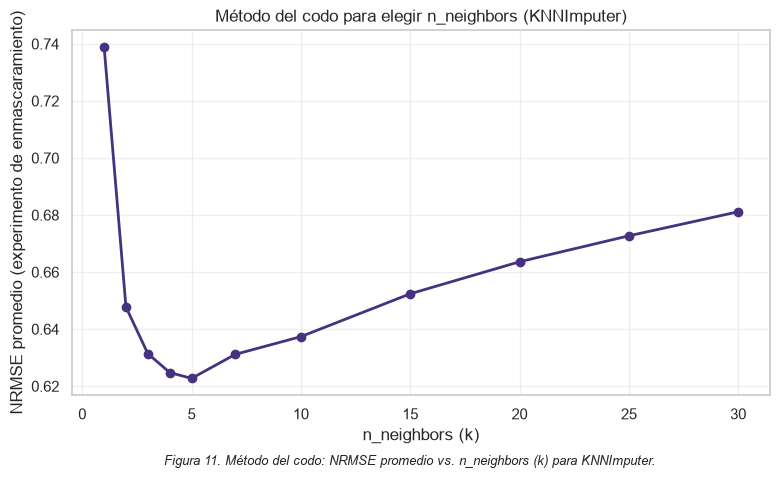

In [40]:
graficar_codo(tabla)

### Interpretamos el resultado

El `k` elegido es el punto donde la curva deja de bajar fuerte y se aplana (o empieza a subir) de forma más brusca.

Derivada segunda del NRMSE por k (curvatura):
    k  derivada_segunda
0   2            0.0750
1   3            0.0097
2   4            0.0046
3   5            0.0042
4   7           -0.0009
5  10            0.0002
6  15           -0.0002
7  20           -0.0001
8  25           -0.0000

k elegido (mayor curvatura, calculado analiticamente): 2


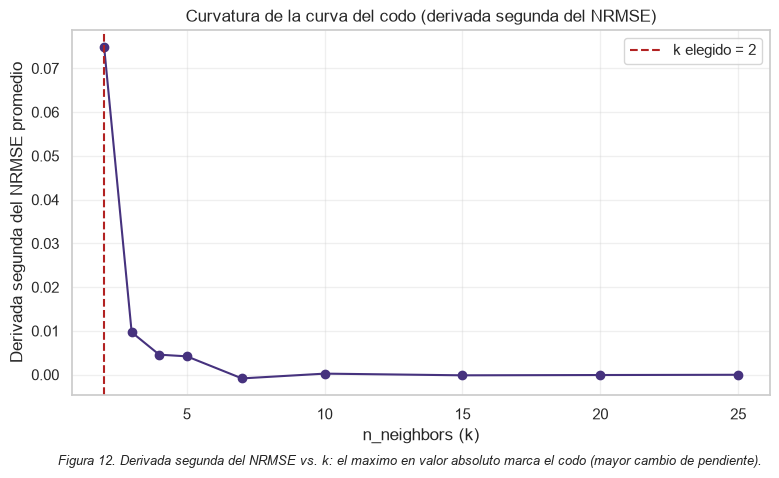

In [41]:
k_minimo, derivadas_codo = elegir_k_por_curvatura(tabla)
print('Derivada segunda del NRMSE por k (curvatura):')
print(derivadas_codo)
print(f'\nk elegido (mayor curvatura, calculado analiticamente): {k_minimo}')

graficar_curvatura_codo(derivadas_codo, k_minimo)


## Imputación final con KNNImputer

Con el `k` elegido imputamos las columnas continuas. Los faltantes de test se completan con vecinos de train.

In [42]:
imputer = KNNImputer(n_neighbors=k_minimo)

X_train_imp = X_train_esc.copy()
X_train_imp[columnas_continuas] = imputer.fit_transform(X_train_esc[columnas_continuas])

X_test_imp = X_test_esc.copy()
X_test_imp[columnas_continuas] = imputer.transform(X_test_esc[columnas_continuas])

print('Nulos restantes en train:', X_train_imp[columnas_continuas].isnull().sum().sum())
print('Nulos restantes en test:', X_test_imp[columnas_continuas].isnull().sum().sum())

Nulos restantes en train: 0
Nulos restantes en test: 0


## Imputación de RAD y CHAS con CatBoostClassifier

Al ser categóricas no se pueden promediar, así que imputarlas es un problema de **clasificación**: `CatBoostClassifier` predice la categoría faltante a partir del resto de las variables. Se entrena con train y el mismo modelo completa test.

In [43]:
from catboost import CatBoostClassifier

for col in ['RAD', 'CHAS']:
    features = [c for c in X_train_imp.columns if c != col]
    conocido = X_train_imp[X_train_imp[col].notna()]

    modelo = CatBoostClassifier(
        iterations=500, learning_rate=0.05, depth=4,
        verbose=False, random_seed=42, allow_writing_files=False,
    )
    modelo.fit(conocido[features], conocido[col].astype(int))

    falta_train = X_train_imp[col].isna()
    falta_test = X_test_imp[col].isna()
    X_train_imp.loc[falta_train, col] = modelo.predict(X_train_imp.loc[falta_train, features]).flatten().astype(float)
    X_test_imp.loc[falta_test, col] = modelo.predict(X_test_imp.loc[falta_test, features]).flatten().astype(float)

print('Nulos restantes en RAD:', X_train_imp['RAD'].isnull().sum() + X_test_imp['RAD'].isnull().sum())
print('Nulos restantes en CHAS:', X_train_imp['CHAS'].isnull().sum() + X_test_imp['CHAS'].isnull().sum())

Nulos restantes en RAD: 0
Nulos restantes en CHAS: 0


## Distribuciones antes y después de imputar

`X_train_esc` (con nulos) contra `X_train_imp`, en la escala de `RobustScaler`. Una buena imputación rellena sin deformar la distribución: la parte azul que sobresale es lo que agregó cada método.

In [44]:
antes = X_train_esc.copy()
antes['Dataset'] = 'Antes de imputar'

despues = X_train_imp.copy()
despues['Dataset'] = 'Después de imputar'

comparacion = pd.concat([antes, despues], ignore_index=True)

In [45]:
comparacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 834 entries, 0 to 833
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     829 non-null    float64
 1   ZN       826 non-null    float64
 2   INDUS    834 non-null    float64
 3   CHAS     830 non-null    float64
 4   NOX      831 non-null    float64
 5   RM       832 non-null    float64
 6   AGE      830 non-null    float64
 7   DIS      834 non-null    float64
 8   RAD      828 non-null    float64
 9   TAX      832 non-null    float64
 10  PTRATIO  831 non-null    float64
 11  B        830 non-null    float64
 12  LSTAT    832 non-null    float64
 13  Dataset  834 non-null    str    
dtypes: float64(13), str(1)
memory usage: 91.3 KB


In [46]:
comparacion.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Dataset
0,-0.0031,0.0000,0.0000,0.0000,0.0328,-0.6667,0.0328,0.2087,4.0000,-0.1039,-0.1061,0.2540,0.0050,Antes de imputar
1,0.0528,0.0000,0.0000,0.0000,0.0328,-0.1194,-0.3314,0.2266,4.0000,-0.1039,-0.1061,0.2451,0.1285,Antes de imputar
2,-0.0470,3.4401,-0.6330,0.0000,-0.6934,0.5057,-0.7726,2.3313,4.0000,0.1739,-0.1364,-0.9386,-0.5984,Antes de imputar
3,2.3290,0.0000,0.6322,0.0000,0.9555,0.7056,0.3487,-0.2459,24.0000,0.8360,0.4394,-17.8735,0.7289,Antes de imputar
4,0.0045,0.0000,-0.1943,0.0000,-0.2457,-0.6626,-0.0328,0.4522,5.0000,-0.1481,0.2576,0.0079,0.0291,Antes de imputar


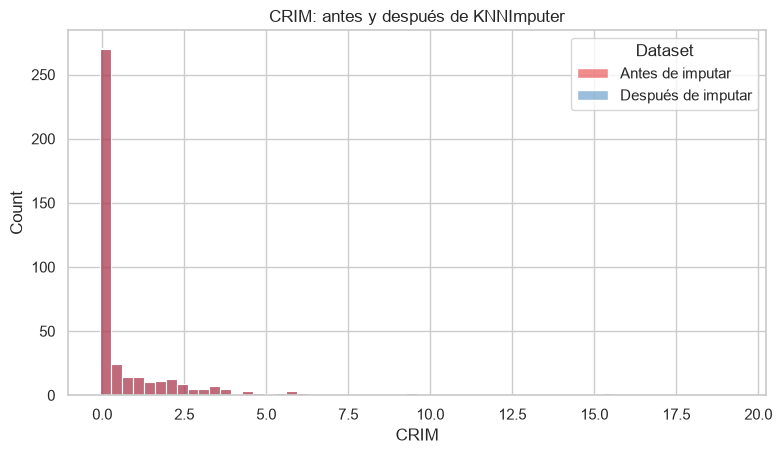

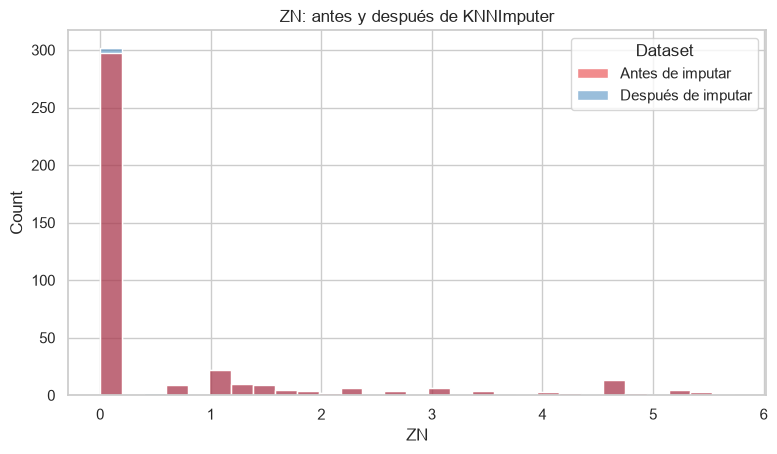

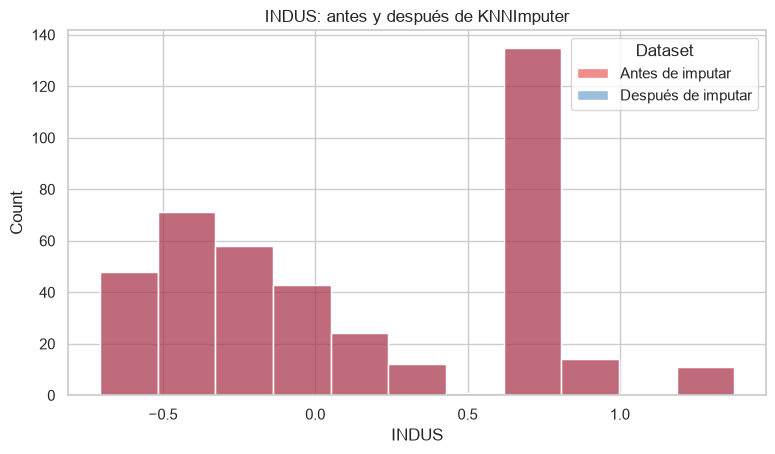

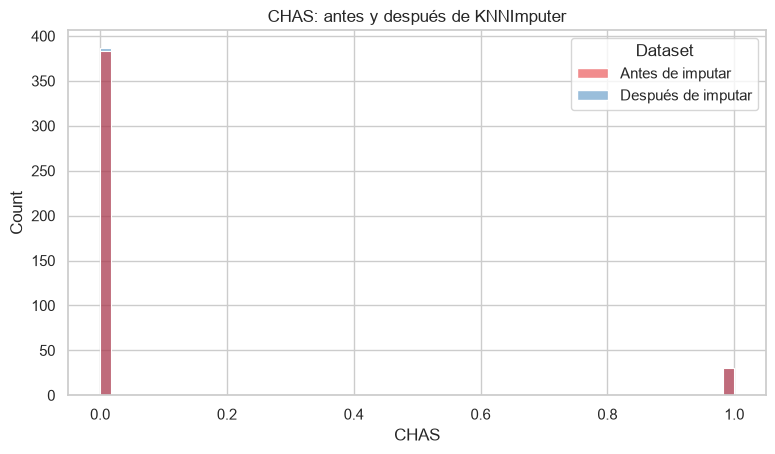

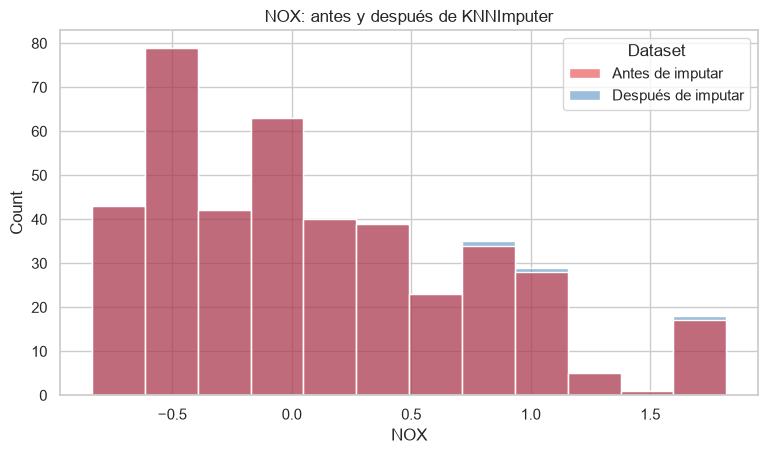

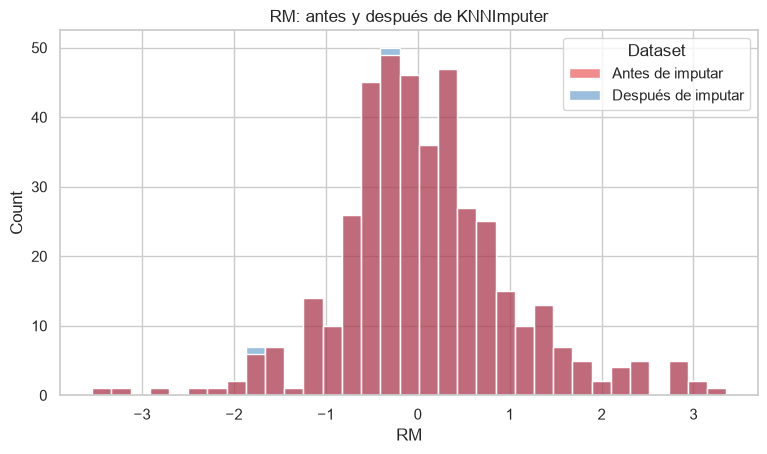

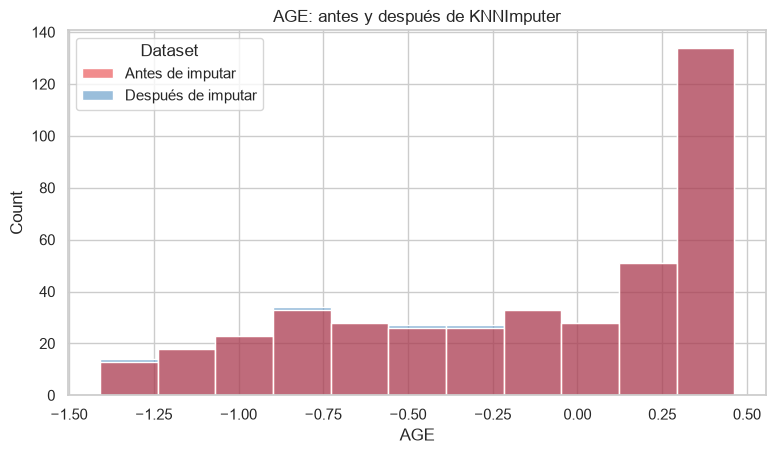

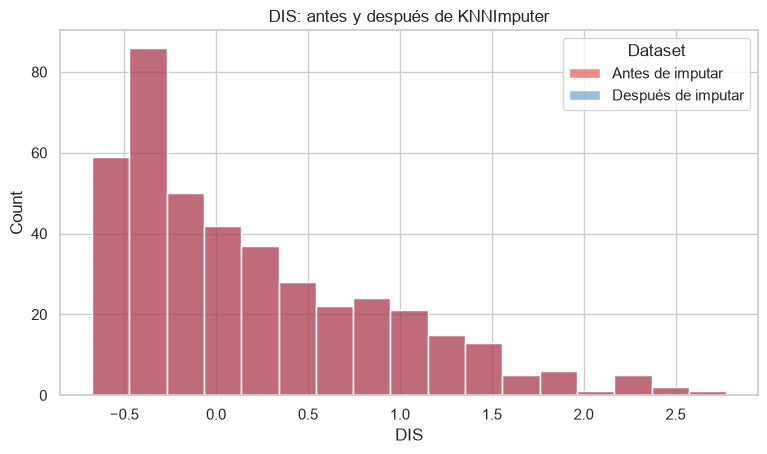

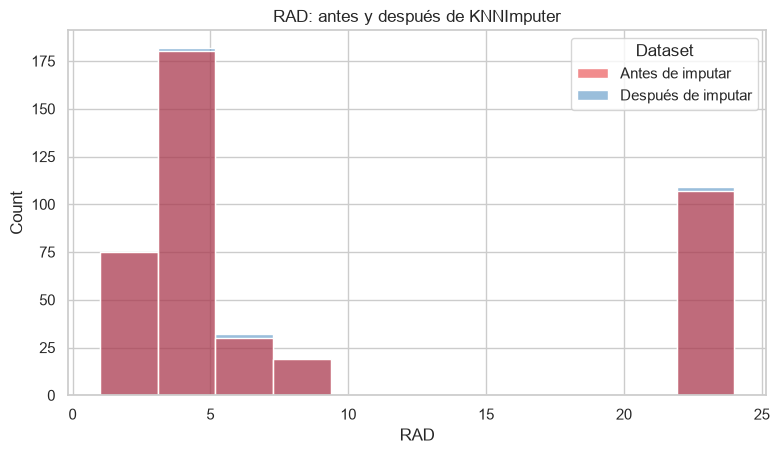

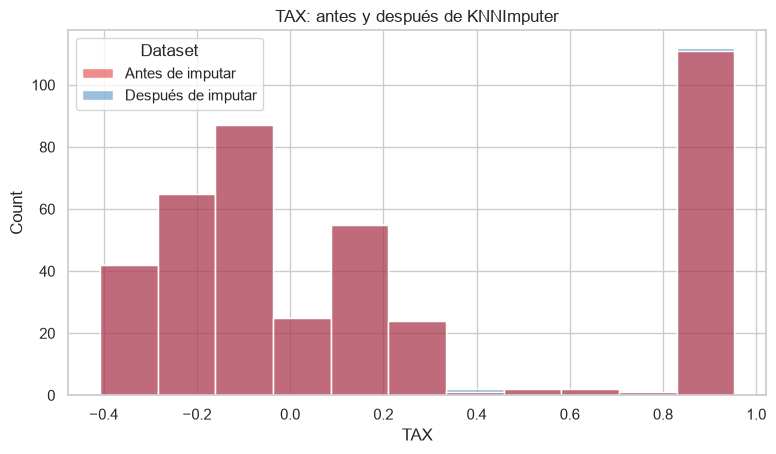

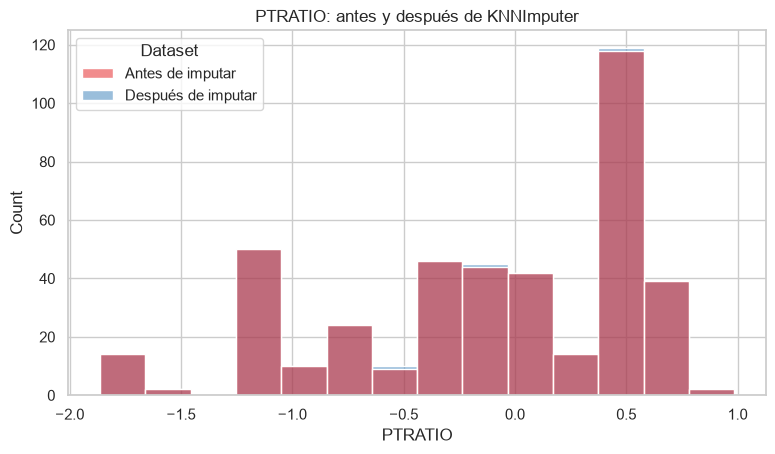

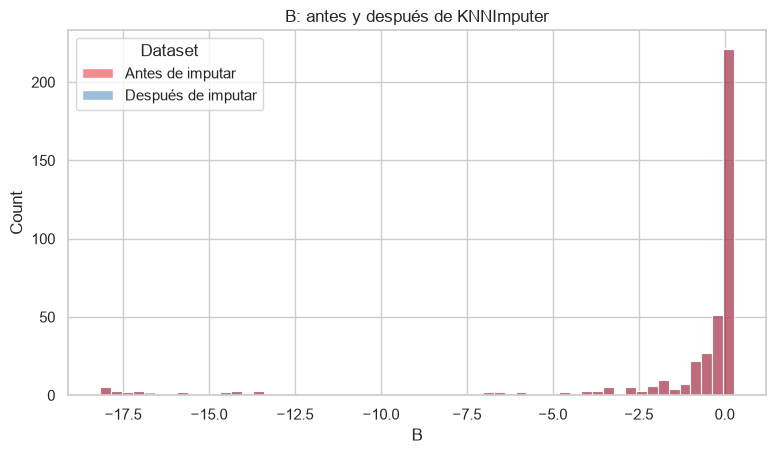

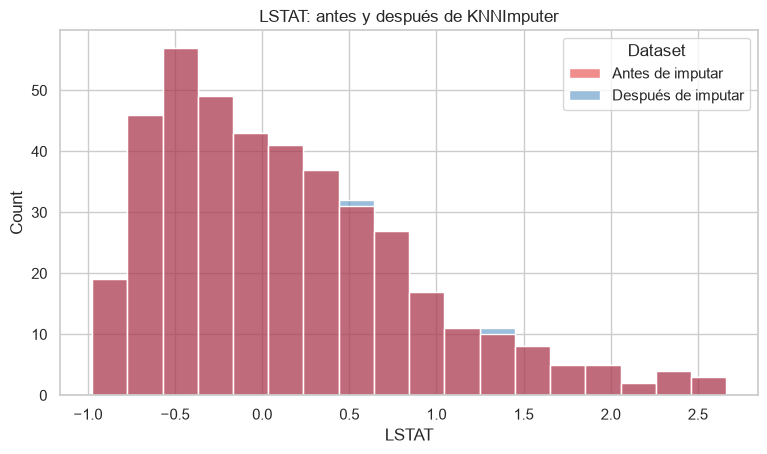

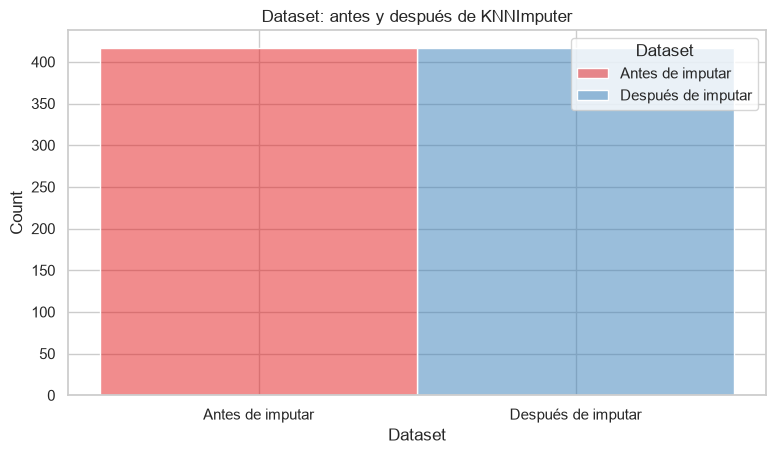

In [47]:
for col in comparacion.columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(data=comparacion, x=col, hue='Dataset', palette='Set1')
    plt.title(f'{col}: antes y después de KNNImputer')
    plt.subplots_adjust(bottom=0.15)
    plt.show()

## Resumen del preprocesamiento

1. Eliminamos las filas sin `MEDV` o con 50% o más de faltantes.
2. Marcamos como nulos los valores inválidos de `RAD`.
3. Revisamos outliers con IQR y su coherencia con la matriz de correlación.
4. Separamos train y test antes de escalar o imputar.
5. Eliminamos de train (nunca de test) las filas incoherentes trianguladas.
6. Escalamos con `RobustScaler`.
7. Imputamos las continuas con `KNNImputer`, con `k` elegido por el método del codo.
8. Imputamos `RAD` y `CHAS` con `CatBoostClassifier`.


# Modelado

Entrenamos una **regresión lineal**, que estima `MEDV` como una suma ponderada de las variables, de dos formas: con `scikit-learn` y con descenso del gradiente programado a mano.

## Regresión lineal con scikit-learn

`LinearRegression` sobre `X_train_imp`, evaluada con MAE, RMSE y R² en train y test. MAE y RMSE quedan en miles de dólares, como `MEDV`.

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_imp, y_train)

pred_train_sk = modelo_lineal.predict(X_train_imp)
pred_test_sk = modelo_lineal.predict(X_test_imp)


def metricas(y_real, y_pred):
    return {
        'MAE': mean_absolute_error(y_real, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_real, y_pred)),
        'R2': r2_score(y_real, y_pred),
    }


metricas_sk = {'Train': metricas(y_train, pred_train_sk), 'Test': metricas(y_test, pred_test_sk)}
pd.DataFrame(metricas_sk).T.round(4)

,MAE,RMSE,R2
Train,3.7005,5.7154,0.6113
Test,4.2010,6.4267,0.6174


In [49]:
print(f'Intercepto: {modelo_lineal.intercept_:.4f}')

coeficientes_sk = pd.Series(modelo_lineal.coef_, index=X_train_imp.columns)
coeficientes_sk.sort_values().round(4)

Intercepto: 22.1959


LSTAT     -4.3599
DIS       -3.5160
AGE       -2.8003
PTRATIO   -2.6829
TAX       -2.2760
INDUS     -0.4300
NOX       -0.1377
CRIM       0.0214
RAD        0.0738
B          0.2276
ZN         0.6522
RM         2.6648
CHAS       4.9313
dtype: float64

## Descenso del gradiente

El **descenso del gradiente** arranca con pesos al azar y los corrige paso a paso en la dirección que más reduce el error cuadrático medio. Seguimos a la cátedra (`Implementaciones-Descenso-del-Gradiente.ipynb`), con tres variantes:

| Variante | Cuándo actualiza los pesos |
|---|---|
| Batch | una vez por época, con el gradiente de todo el conjunto |
| Estocástico (SGD) | una vez por muestra |
| Mini-batch | una vez por lote de muestras |

Todas usan `y_pred = X @ W`, con una columna de unos para el término independiente, y actualizan con `W = W - lr · gradiente`. El batch corta por tolerancia; las otras dos, que oscilan, por un número fijo de épocas.

`RAD` (hasta 24) y `CHAS` (0 o 1) no pasaron por `RobustScaler`, y con escalas tan mezcladas una tasa razonable hace diverger al algoritmo. Por eso estandarizamos para entrenar y después devolvemos los pesos a la escala original, para compararlos con `scikit-learn`.

In [50]:
from sklearn.preprocessing import StandardScaler

escalador_gd = StandardScaler()
X_train_gd = escalador_gd.fit_transform(X_train_imp)
X_test_gd = escalador_gd.transform(X_test_imp)

y_train_gd = y_train.to_numpy(dtype=float).reshape(-1, 1)
y_test_gd = y_test.to_numpy(dtype=float).reshape(-1, 1)

### Variante 1: batch

Un gradiente por época con las 417 filas de train. Es la más estable y tolera la tasa más alta, pero cada paso recorre todo el dataset.

In [51]:
def descenso_gradiente_batch(X_tr, y_tr, X_te, y_te, lr=0.1, epocas=3000, tolerancia=1e-9, semilla=42):
    n, m = X_tr.shape

    # Columna de unos para el término independiente
    X_tr = np.hstack((np.ones((n, 1)), X_tr))
    X_te = np.hstack((np.ones((X_te.shape[0], 1)), X_te))

    W = np.random.default_rng(semilla).standard_normal((m + 1, 1))

    error_train, error_test = [], []
    for _ in range(epocas):
        residuo = y_tr - X_tr @ W
        error_train.append(float(np.mean(residuo ** 2)))
        error_test.append(float(np.mean((y_te - X_te @ W) ** 2)))

        gradiente = -2 / n * (X_tr.T @ residuo)
        W = W - lr * gradiente

        if len(error_train) > 1 and abs(error_train[-2] - error_train[-1]) < tolerancia:
            break

    return W, error_train, error_test

### Variante 2: estocástico (SGD)

Actualiza con cada muestra, 417 veces por época. Avanza rápido pero con ruido, y necesita una tasa mucho más chica.

In [52]:
def descenso_gradiente_estocastico(X_tr, y_tr, X_te, y_te, lr=0.0005, epocas=100, semilla=42):
    n, m = X_tr.shape

    X_tr = np.hstack((np.ones((n, 1)), X_tr))
    X_te = np.hstack((np.ones((X_te.shape[0], 1)), X_te))

    W = np.random.default_rng(semilla).standard_normal((m + 1, 1))
    rng = np.random.default_rng(semilla)

    error_train, error_test = [], []
    for _ in range(epocas):
        # Se mezclan los datos en cada época
        orden = rng.permutation(n)
        X_mezclado, y_mezclado = X_tr[orden], y_tr[orden]

        for j in range(n):
            x_muestra = X_mezclado[j:j + 1]
            residuo = y_mezclado[j:j + 1] - x_muestra @ W
            W = W - lr * (-2 * x_muestra.T @ residuo)

        # El error se mide sobre todo el conjunto al cerrar la época, para poder comparar variantes
        error_train.append(float(np.mean((y_tr - X_tr @ W) ** 2)))
        error_test.append(float(np.mean((y_te - X_te @ W) ** 2)))

    return W, error_train, error_test

### Variante 3: mini-batch

Gradiente sobre lotes de 64 filas: menos ruido que el estocástico, sin el costo de recorrer todo el dataset en cada paso.

In [53]:
def descenso_gradiente_mini_batch(X_tr, y_tr, X_te, y_te, lr=0.01, epocas=300, batch_size=64, semilla=42):
    n, m = X_tr.shape

    X_tr = np.hstack((np.ones((n, 1)), X_tr))
    X_te = np.hstack((np.ones((X_te.shape[0], 1)), X_te))

    W = np.random.default_rng(semilla).standard_normal((m + 1, 1))
    rng = np.random.default_rng(semilla)

    error_train, error_test = [], []
    for _ in range(epocas):
        orden = rng.permutation(n)
        X_mezclado, y_mezclado = X_tr[orden], y_tr[orden]

        for j in range(0, n, batch_size):
            X_lote = X_mezclado[j:j + batch_size]
            y_lote = y_mezclado[j:j + batch_size]
            residuo = y_lote - X_lote @ W
            W = W - lr * (-2 / X_lote.shape[0] * (X_lote.T @ residuo))

        error_train.append(float(np.mean((y_tr - X_tr @ W) ** 2)))
        error_test.append(float(np.mean((y_te - X_te @ W) ** 2)))

    return W, error_train, error_test

### Entrenamiento de las tres variantes

Cada una tiene su propia tasa: la del batch (0.1) hace diverger a las otras dos, que actualizan muchas más veces por época.

In [54]:
W_batch, err_train_batch, err_test_batch = descenso_gradiente_batch(
    X_train_gd, y_train_gd, X_test_gd, y_test_gd, lr=0.1, epocas=3000
)

W_sgd, err_train_sgd, err_test_sgd = descenso_gradiente_estocastico(
    X_train_gd, y_train_gd, X_test_gd, y_test_gd, lr=0.0005, epocas=100
)

W_mb, err_train_mb, err_test_mb = descenso_gradiente_mini_batch(
    X_train_gd, y_train_gd, X_test_gd, y_test_gd, lr=0.01, epocas=300, batch_size=64
)

for nombre, errores in [('Batch', err_train_batch),
                        ('Estocástico', err_train_sgd),
                        ('Mini-batch', err_train_mb)]:
    print(f'{nombre:<13} épocas: {len(errores):>4} | MSE final en train: {errores[-1]:.4f}')

Batch         épocas:  461 | MSE final en train: 32.6660
Estocástico   épocas:  100 | MSE final en train: 32.6859
Mini-batch    épocas:  300 | MSE final en train: 32.6715


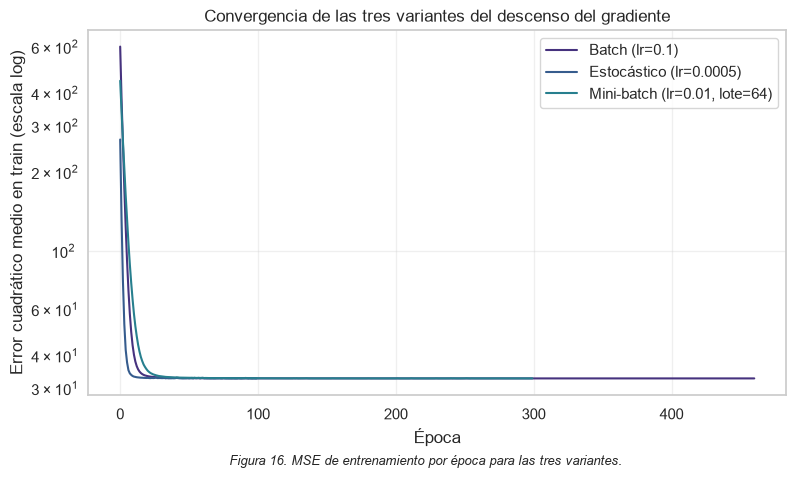

In [55]:
plt.figure(figsize=(9, 5))
plt.plot(err_train_batch, label='Batch (lr=0.1)')
plt.plot(err_train_sgd, label='Estocástico (lr=0.0005)')
plt.plot(err_train_mb, label='Mini-batch (lr=0.01, lote=64)')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('Error cuadrático medio en train (escala log)')
plt.title('Convergencia de las tres variantes del descenso del gradiente')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 16. MSE de entrenamiento por época para las tres variantes.',
            ha='center', fontsize=9, style='italic')
plt.show()

El error de test solo se guarda para inspección; no interviene en el entrenamiento.

In [56]:
# Los pesos se aprendieron sobre features estandarizadas: los devolvemos a la escala original
def recuperar_parametros(W):
    coeficientes = W[1:, 0] / escalador_gd.scale_
    intercepto = W[0, 0] - np.sum(W[1:, 0] * escalador_gd.mean_ / escalador_gd.scale_)
    return coeficientes, intercepto


resultados_gd = {}
for nombre, W in [('Batch', W_batch), ('Estocástico', W_sgd), ('Mini-batch', W_mb)]:
    coeficientes, intercepto = recuperar_parametros(W)
    resultados_gd[nombre] = {
        'coeficientes': coeficientes,
        'intercepto': intercepto,
        'Train': metricas(y_train, X_train_imp @ coeficientes + intercepto),
        'Test': metricas(y_test, X_test_imp @ coeficientes + intercepto),
    }
    print(f'{nombre:<13} intercepto: {intercepto:.4f}')

Batch         intercepto: 22.1962
Estocástico   intercepto: 22.1641
Mini-batch    intercepto: 22.1833


### Gráficas de error vs iteraciones (enfoque de la cátedra)

El punto 4 pide *"incorporar gráficas de Error vs Iteraciones (loss vs epochs)"*, que muestran si la **función de costo** converge, oscila o diverge. Usamos las funciones de la cátedra sin cambios (`Implementaciones-Descenso-del-Gradiente.ipynb`, celdas 2 a 4) con sus parámetros (celdas 19 a 21): 200 épocas, `lr=0.01` y lote de 11.

En batch, la curva de *validación* es en realidad test (como en la cátedra) y cada punto es una época; en estocástico y mini-batch, cada punto es una actualización.

#### Batch

Una actualización por época sobre todo el conjunto, así que las curvas deberían bajar suaves.

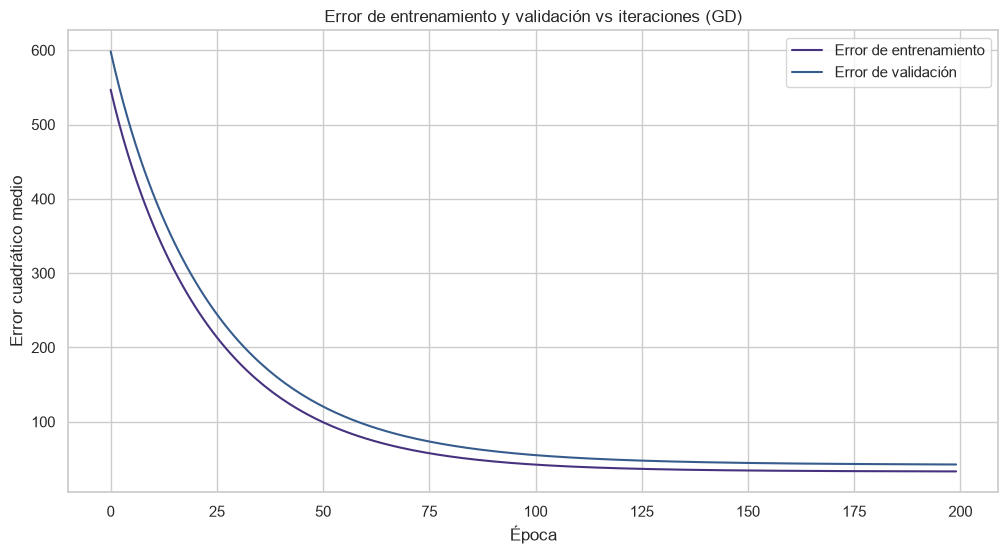

In [57]:
# Fuente: Implementaciones-Descenso-del-Gradiente.ipynb, celda 2 (función sin modificar)
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """Gradient Descent (batch). Docstring completo en el notebook de la cátedra."""

    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    # Definir una figura
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    # Activar la leyenda
    plt.legend()
    # Poner titulo
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    # Terminar y mostrar gráfico
    plt.show()

    return W


# Parámetros de la cátedra sobre datos estandarizados (celda 19)
np.random.seed(42)
W_catedra_gd = gradient_descent(X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01)

#### Estocástico (SGD)

Unas 83.400 actualizaciones en total. La curva de train mide una sola muestra por vez y es ruidosa por construcción; conviene mirar la de test.

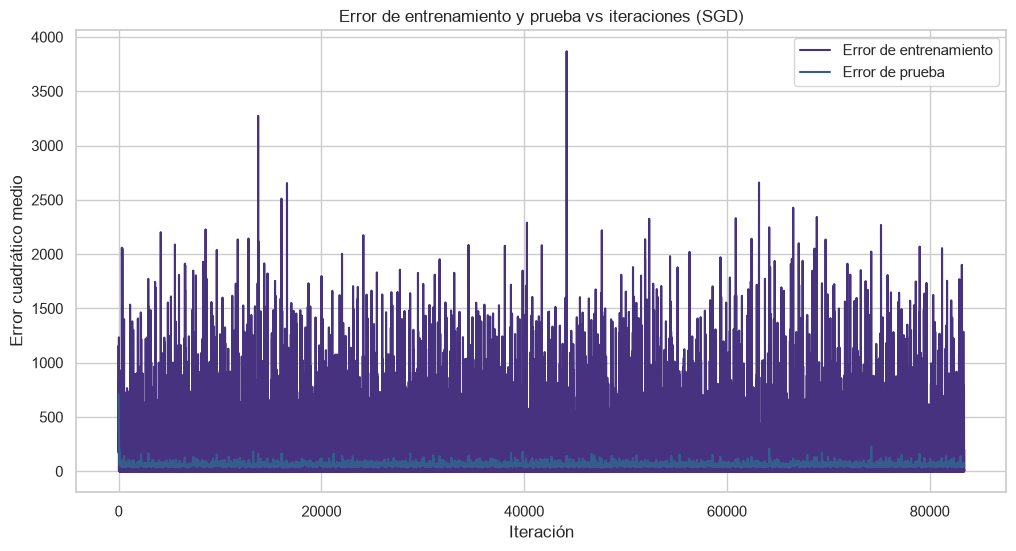

In [58]:
# Fuente: Implementaciones-Descenso-del-Gradiente.ipynb, celda 3 (función sin modificar)
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """Stochastic Gradient Descent. Docstring completo en el notebook de la cátedra."""

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W


# Parámetros de la cátedra sobre datos estandarizados (celda 20)
W_catedra_sgd = stochastic_gradient_descent(X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01)

#### Mini-batch

38 lotes de 11 por época: oscila menos que el estocástico y más que el batch.

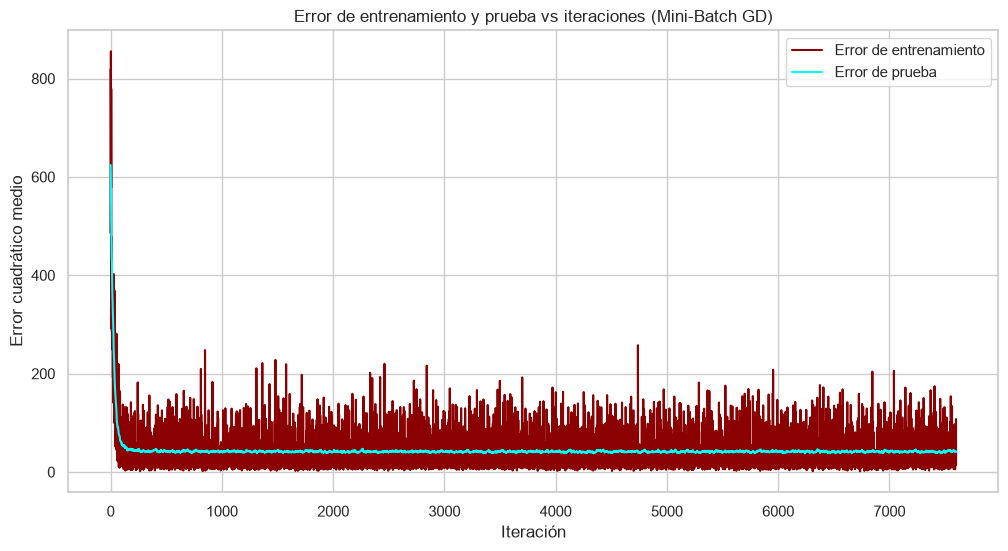

In [59]:
# Fuente: Implementaciones-Descenso-del-Gradiente.ipynb, celda 4 (función sin modificar)
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    """Mini-Batch Gradient Descent. Docstring completo en el notebook de la cátedra."""

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento', color = 'darkred')
    plt.plot(test_errors, label='Error de prueba', color = 'cyan')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W


# Parámetros de la cátedra sobre datos estandarizados (celda 21)
W_catedra_mb = mini_batch_gradient_descent(X_train_gd, y_train_gd, X_test_gd, y_test_gd, epochs=200, lr=0.01)

#### ¿Algún cambio?

Sí. Con `lr=0.01` el batch baja suave pero no llega al mínimo en 200 épocas (por eso usamos 0.1), y el mini-batch converge rápido. El estocástico oscila sin asentarse: como en nuestra versión, necesita una tasa mucho menor (0.0005). Cuantas más actualizaciones por época, más chica tiene que ser la **tasa de aprendizaje**.

## Comparación de los métodos

In [60]:
comparacion_coeficientes = pd.DataFrame(
    {'scikit-learn': modelo_lineal.coef_,
     **{f'GD {nombre}': r['coeficientes'] for nombre, r in resultados_gd.items()}},
    index=X_train_imp.columns,
)
comparacion_coeficientes.round(4)

,scikit-learn,GD Batch,GD Estocástico,GD Mini-batch
CRIM,0.0214,0.0213,0.0303,0.0126
ZN,0.6522,0.6522,0.6533,0.6367
INDUS,-0.4300,-0.4302,-0.4040,-0.4550
CHAS,4.9313,4.9314,4.9516,4.9110
NOX,-0.1377,-0.1377,-0.1050,-0.1552
RM,2.6648,2.6648,2.6489,2.6522
AGE,-2.8003,-2.8003,-2.7940,-2.7720
DIS,-3.5160,-3.5161,-3.5326,-3.5416
RAD,0.0738,0.0738,0.0715,0.0759
TAX,-2.2760,-2.2750,-2.1469,-2.1907


In [61]:
comparacion_metricas = pd.DataFrame({
    ('scikit-learn', 'Train'): metricas_sk['Train'],
    ('scikit-learn', 'Test'): metricas_sk['Test'],
    **{(f'GD {nombre}', particion): r[particion]
       for nombre, r in resultados_gd.items()
       for particion in ['Train', 'Test']},
}).T
comparacion_metricas.round(4)

MAE   RMSE     R2
scikit-learn   Train 3.7005 5.7154 0.6113
               Test  4.2010 6.4267 0.6174
GD Batch       Train 3.7005 5.7154 0.6113
               Test  4.2010 6.4267 0.6174
GD Estocástico Train 3.7040 5.7172 0.6111
               Test  4.1891 6.4359 0.6163
GD Mini-batch  Train 3.7011 5.7159 0.6112
               Test  4.2114 6.4559 0.6140

### Lectura de la comparación

Los cuatro métodos llegan casi a la misma solución porque el costo de la regresión lineal es **convexo** y tiene un único mínimo. El batch coincide con `scikit-learn` hasta el cuarto decimal; el estocástico y el mini-batch quedan a unas milésimas porque oscilan alrededor del mínimo, pero convergen en menos épocas (100 contra 461). Con 417 filas el costo computacional no importa: el descenso del gradiente se vuelve necesario cuando el volumen de datos hace inviable la solución analítica.

## Regularización: Ridge, Lasso y ElasticNet

La **regularización** le suma al error un castigo por el tamaño de los coeficientes, para frenar el sobreajuste: Ridge usa sus cuadrados (L2), Lasso sus valores absolutos (L1) y ElasticNet ambos. Como la cátedra (`Regularizacion2.ipynb`, celdas 46, 58 y 69), cada modelo va en un pipeline con `StandardScaler` y la versión `CV` elige `alpha` por validación cruzada en train. Sacamos `l1_ratio=0` de ElasticNet porque equivale a Ridge y no converge bien.

Escalar es obligatorio: sin eso, el castigo dependería de las unidades de cada variable (Clase 5, diapositiva 18).

In [62]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

modelos_reg = {
    'Ridge': make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-4, 6, 200))),
    'Lasso': make_pipeline(StandardScaler(), LassoCV(alphas=np.logspace(-4, 2, 200), cv=5)),
    'ElasticNet': make_pipeline(StandardScaler(), ElasticNetCV(
        l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 0.99], alphas=np.logspace(-3, 6, 200), cv=10)),
}

for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_imp, y_train)
    extra = f' | l1_ratio: {modelo[-1].l1_ratio_}' if nombre == 'ElasticNet' else ''
    print(f'{nombre:<11} alpha elegido: {modelo[-1].alpha_:.4g}{extra}')

Ridge       alpha elegido: 67.48
Lasso       alpha elegido: 0.111
ElasticNet  alpha elegido: 0.1482 | l1_ratio: 0.5


Coeficientes en escala estandarizada: se comparan entre sí, pero no con los de la regresión lineal. Los ceros de Lasso son variables descartadas.

In [63]:
pd.DataFrame(
    {nombre: modelo[-1].coef_ for nombre, modelo in modelos_reg.items()},
    index=X_train_imp.columns,
).round(4)

,Ridge,Lasso,ElasticNet
CRIM,-0.1887,-0.0000,-0.0775
ZN,0.5818,0.5748,0.5467
INDUS,-0.3153,-0.1844,-0.2472
CHAS,1.1827,1.1868,1.1726
NOX,-0.0911,-0.0000,-0.0000
RM,2.3984,2.5212,2.4699
AGE,-1.0108,-1.2267,-1.0769
DIS,-1.4558,-1.8180,-1.5509
RAD,0.1900,0.0000,0.0000
TAX,-0.5851,-0.3462,-0.4183


### Métricas en train y test

MAE y RMSE están en miles de dólares, como `MEDV` (el RMSE castiga más los errores grandes), y R² es la proporción de la variabilidad del precio que explica el modelo. Descartamos el MSE, que es el RMSE al cuadrado, y el MAPE, que se infla en las casas baratas.

In [64]:
comparacion_reg = {('LinearRegression', p): metricas_sk[p] for p in ['Train', 'Test']}
for nombre, modelo in modelos_reg.items():
    comparacion_reg[(nombre, 'Train')] = metricas(y_train, modelo.predict(X_train_imp))
    comparacion_reg[(nombre, 'Test')] = metricas(y_test, modelo.predict(X_test_imp))

pd.DataFrame(comparacion_reg).T.round(4)

MAE   RMSE     R2
LinearRegression Train 3.7005 5.7154 0.6113
                 Test  4.2010 6.4267 0.6174
Ridge            Train 3.7545 5.7791 0.6026
                 Test  4.2078 6.5089 0.6076
Lasso            Train 3.7235 5.7393 0.6080
                 Test  4.2354 6.4793 0.6112
ElasticNet       Train 3.7439 5.7602 0.6052
                 Test  4.2167 6.4774 0.6114

### ¿Por qué medir en ambos conjuntos?

Train dice qué tan bien el modelo ajusta lo que ya vio; test, qué tan bien predice datos nuevos. Compararlos es el diagnóstico de **sobreajuste y subajuste**:

| Train | Test | Diagnóstico |
|---|---|---|
| bueno | mucho peor | sobreajuste (overfitting) |
| malo | malo | subajuste (underfitting) |
| bueno | parecido | buen ajuste |

### ¿Conseguimos un buen fitting?

No hay sobreajuste: train y test dan casi igual (R² de 0.61 y 0.62 en la regresión lineal). Por eso regularizar cambia los coeficientes, sobre todo los de variables correlacionadas como `RAD` y `TAX`, pero no mejora las métricas.

Sí hay algo de subajuste: el modelo deja sin explicar cerca del 40% de la variabilidad y erra entre 3.700 (MAE) y 6.500 dólares (RMSE). El límite es el propio modelo lineal; para mejorar haría falta más flexibilidad (términos polinómicos o interacciones), no más regularización.

# Optimización de hiperparámetros

Los **hiperparámetros** (tasa de aprendizaje, tamaño de lote, `alpha`) se fijan antes de entrenar. Variamos uno por vez, con el resto fijo.

## Descenso del gradiente: tasa de aprendizaje

Como la cátedra (`Regresion_Lineal_Descenso_Gradiente_AAI.ipynb`, sección 4), probamos varias `lr` en el batch. El límite de convergencia se calcula: 2 dividido el autovalor más grande de `2/n · XᵀX`. Probamos tres valores chicos y dos pegados al límite, uno de cada lado.

lr máximo para que el batch converja: 0.176


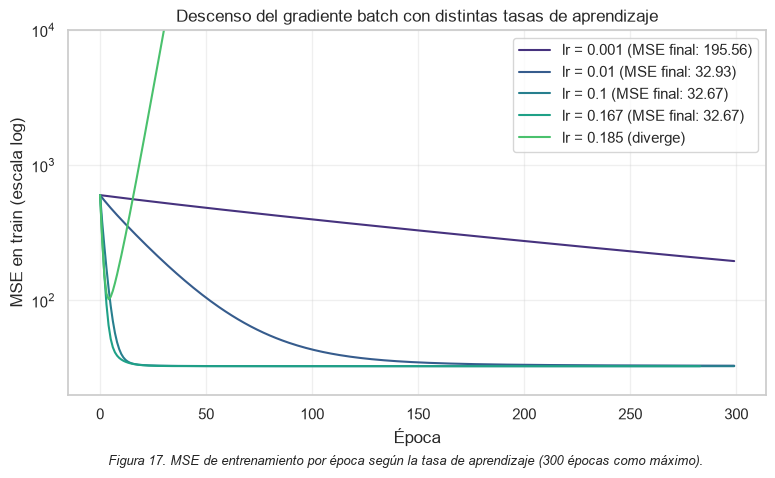

In [65]:
X_con_unos = np.hstack((np.ones((len(X_train_gd), 1)), X_train_gd))
lr_max = 2 / np.linalg.eigvalsh(2 / len(X_con_unos) * X_con_unos.T @ X_con_unos).max()
print(f'lr máximo para que el batch converja: {lr_max:.3f}')

plt.figure(figsize=(9, 5))
for lr in [0.001, 0.01, 0.1, round(0.95 * lr_max, 3), round(1.05 * lr_max, 3)]:
    with np.errstate(over='ignore', invalid='ignore'):
        _, err_train, _ = descenso_gradiente_batch(X_train_gd, y_train_gd, X_test_gd, y_test_gd, lr=lr, epocas=300)
    final = f'MSE final: {err_train[-1]:.2f}' if err_train[-1] < 1e4 else 'diverge'
    plt.plot(err_train, label=f'lr = {lr} ({final})')
plt.yscale('log')
plt.ylim(20, 1e4)
plt.xlabel('Época')
plt.ylabel('MSE en train (escala log)')
plt.title('Descenso del gradiente batch con distintas tasas de aprendizaje')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 17. MSE de entrenamiento por época según la tasa de aprendizaje (300 épocas como máximo).',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?** Con `lr` chico converge lento (con 0.001 no llega en 300 épocas); al subirla converge más rápido (0.1 tarda unas 30 épocas). Pasado el límite, cada paso saltea el mínimo y el error explota. La mejor tasa es la más grande que todavía converge.

## Descenso del gradiente: tamaño del lote

Con `lr=0.01` y 100 épocas fijas variamos el lote. Un lote de 1 es el estocástico; uno de todo train, el batch.

lote    1 | MSE train: 36.93 | MSE test: 43.45
lote    8 | MSE train: 32.98 | MSE test: 41.92
lote   32 | MSE train: 32.91 | MSE test: 42.18
lote  128 | MSE train: 32.82 | MSE test: 42.55
lote  417 | MSE train: 43.37 | MSE test: 56.44


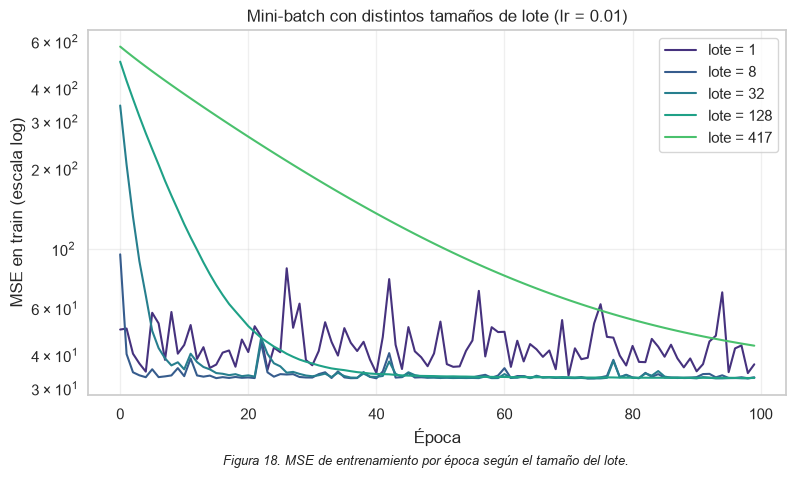

In [66]:
tamanos_lote = [1, 8, 32, 128, len(X_train_gd)]

plt.figure(figsize=(9, 5))
for tamano in tamanos_lote:
    _, err_train, err_test = descenso_gradiente_mini_batch(
        X_train_gd, y_train_gd, X_test_gd, y_test_gd, lr=0.01, epocas=100, batch_size=tamano
    )
    plt.plot(err_train, label=f'lote = {tamano}')
    print(f'lote {tamano:>4} | MSE train: {err_train[-1]:.2f} | MSE test: {err_test[-1]:.2f}')
plt.yscale('log')
plt.xlabel('Época')
plt.ylabel('MSE en train (escala log)')
plt.title('Mini-batch con distintos tamaños de lote (lr = 0.01)')
plt.legend()
plt.grid(alpha=0.3)
plt.subplots_adjust(bottom=0.15)
plt.figtext(0.5, 0.01, 'Figura 18. MSE de entrenamiento por época según el tamaño del lote.',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?** Los lotes chicos actualizan más veces y bajan más rápido por época; el lote completo no converge en 100 épocas. Pero el lote de 1 es tan ruidoso que queda rebotando alrededor del mínimo. Los intermedios equilibran ambos extremos, por eso el mini-batch es el más usado. Con lotes más chicos conviene bajar la tasa.

## Ridge y Lasso: variación de alpha

Recorremos `alpha` en escala logarítmica, como la cátedra (`Regularizacion2.ipynb`, celdas 48, 59 y 61). La línea punteada es el `alpha` elegido por validación cruzada.

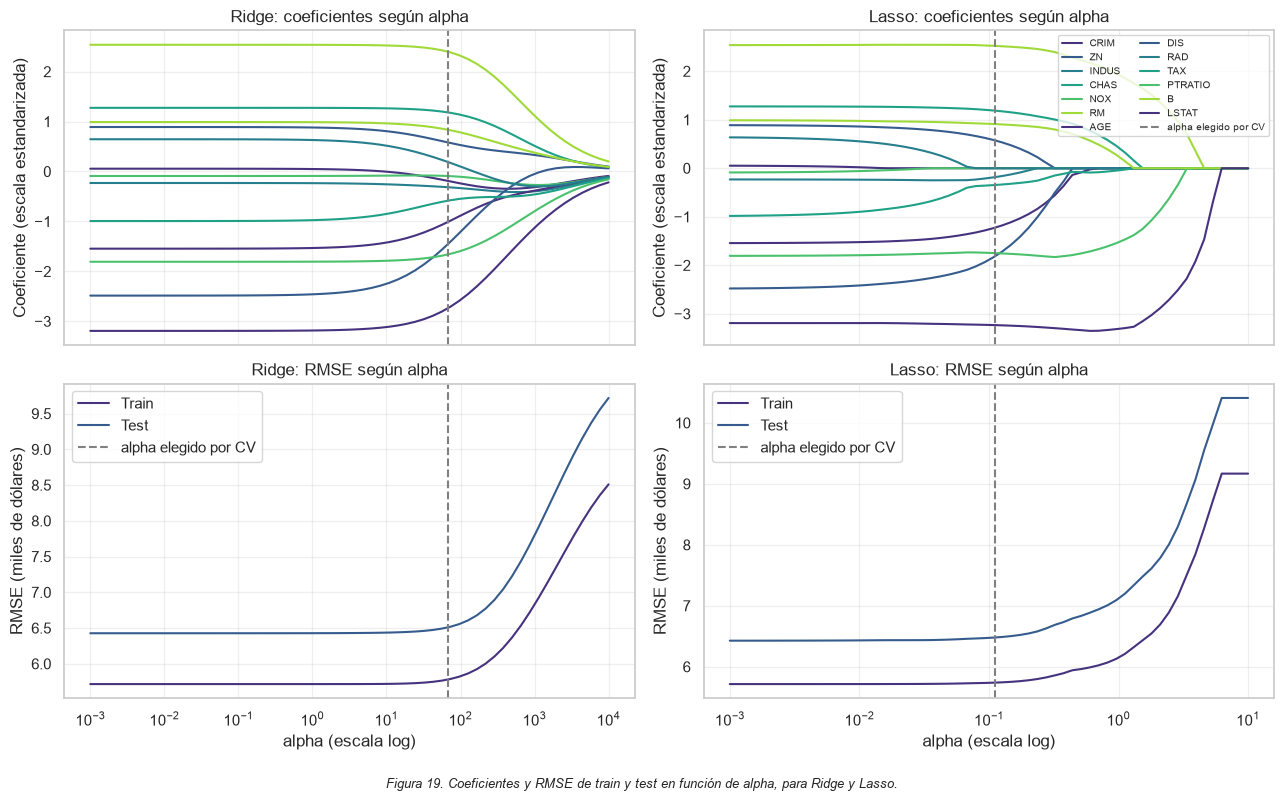

In [67]:
from sklearn.linear_model import Ridge, Lasso

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex='col')
for col, (nombre, Modelo, alphas) in enumerate([('Ridge', Ridge, np.logspace(-3, 4, 60)),
                                                ('Lasso', Lasso, np.logspace(-3, 1, 60))]):
    coefs, rmse_train, rmse_test = [], [], []
    for alpha in alphas:
        modelo = make_pipeline(StandardScaler(), Modelo(alpha=alpha)).fit(X_train_imp, y_train)
        coefs.append(modelo[-1].coef_)
        rmse_train.append(metricas(y_train, modelo.predict(X_train_imp))['RMSE'])
        rmse_test.append(metricas(y_test, modelo.predict(X_test_imp))['RMSE'])

    axes[0, col].plot(alphas, coefs)
    axes[0, col].set_title(f'{nombre}: coeficientes según alpha')
    axes[0, col].set_ylabel('Coeficiente (escala estandarizada)')
    axes[1, col].plot(alphas, rmse_train, label='Train')
    axes[1, col].plot(alphas, rmse_test, label='Test')
    axes[1, col].set_title(f'{nombre}: RMSE según alpha')
    axes[1, col].set_ylabel('RMSE (miles de dólares)')
    axes[1, col].set_xlabel('alpha (escala log)')
    for ax in axes[:, col]:
        ax.set_xscale('log')
        ax.axvline(modelos_reg[nombre][-1].alpha_, color='gray', ls='--', label='alpha elegido por CV')
        ax.grid(alpha=0.3)
    axes[1, col].legend()

axes[0, 1].legend(list(X_train_imp.columns) + ['alpha elegido por CV'], fontsize=7, ncol=2)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.figtext(0.5, 0.005, 'Figura 19. Coeficientes y RMSE de train y test en función de alpha, para Ridge y Lasso.',
            ha='center', fontsize=9, style='italic')
plt.show()

**¿Qué observamos?**

- Con `alpha` chico, ambos equivalen a la regresión lineal.
- Ridge achica todos los coeficientes sin llevar ninguno a cero; Lasso los va anulando hasta que el modelo solo predice el promedio.
- El error de train sube siempre con `alpha`.
- El de test nunca baja: no aparece la U típica del sobreajuste. Es el **compromiso entre sesgo y varianza**: sin varianza de sobra, regularizar solo suma sesgo.

El `alpha` de la validación cruzada cae al final de la zona plana y se aleja de la regresión lineal en menos de una décima de RMSE, así que optimizarlo casi no cambia el resultado.